Importation de la base de donnée

In [1]:
#import pandas as pd

#dfs = pd.read_excel("/Users/matteoschweizer/Desktop/M1_SSD/projetNa/Base de données projet.xlsx", sheet_name=None)  # dict: nom_feuille -> DataFrame
#dfs
#dfs = dfs['Feuille 1']

In [ ]:
# Exemple d'accès à une feuille:
#df_feuil2 = dfs["Country Results 2022 Ed (2018)"]

In [ ]:
#dfs.head()

NameError: name 'dfs' is not defined

In [1]:
import pandas as pd

# Chemin du fichier CSV de sortie
csv_file = "/Users/matteoschweizer/Desktop/M1_SSD/projetNa/project_bd.csv"

df = pd.read_csv(csv_file)

# Exporter en CSV
#df.to_csv(csv_file, index=False)

# Lire le CSV
#data = pd.read_csv(csv_file)

# Afficher les 5 premières lignes
df.head()

,Country,Quality Score,SDGi,Life Expectancy,HDI,Per Capita GDP,Region,Income Group,Population (millions),Cropland Footprint,...,Cropland,Grazing land,Forest land,Fishing ground,Built up land.2,Total biocapacity,Ecological (Deficit) or Reserve,Number of Earths required,Number of Countries required,actual \nCountry Overshoot Day \n2018
0,Afghanistan,3A,53.9,64.486,0.509,564.6173825447371,Middle East/Central Asia,LI,37.171898,0.139393,...,0.139393,0.157740,0.014377,0.000000,0.028433,0.339943,-0.342312,0.431091,2.006970,NaN
1,Albania,3A,71.0,78.458,0.792,5046.032611084467,Other Europe,UM,2.882740,0.362065,...,0.362065,0.195718,0.310590,0.082072,0.042248,0.992693,-0.893765,1.191981,1.900343,1900-11-01 05:06:29.557
2,Algeria,3A,70.9,76.693,0.746,4759.830053642441,Africa,UM,42.228398,0.249653,...,0.249653,0.249356,0.025333,0.007541,0.037283,0.569166,-1.771742,1.479132,4.112872,1900-09-02 18:23:39.042
3,Angola,3A,50.3,60.782,0.582,3233.902767090789,Africa,LM,30.809801,0.210919,...,0.210919,0.918249,0.486000,0.175160,0.046437,1.836766,0.974922,0.544567,0.469218,NaN
4,Antigua and Barbuda,2B,NaN,76.885,0.772,15134.910089609682,Central America/Caribbean,HI,0.096286,NaN,...,NaN,NaN,NaN,NaN,NaN,0.856509,-3.798584,2.941377,5.434962,1900-05-03 02:11:50.646


In [2]:
df_subset = df[(df["Country"] >= "Morocco") & (df["Country"] <= "Solomon Islands")]
len(df_subset)

38

In [ ]:
df_subset

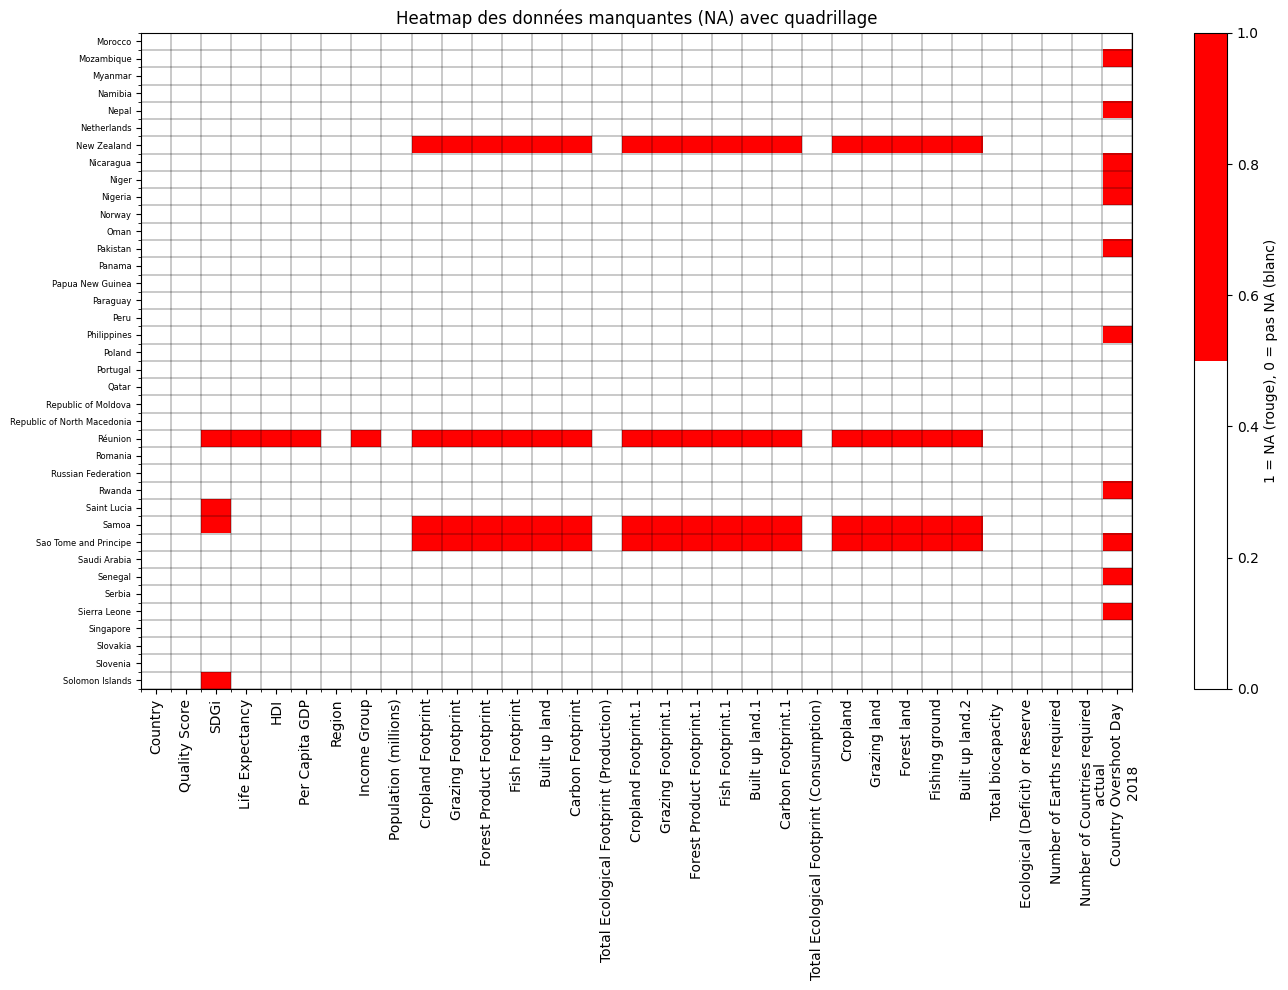

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Matrice binaire : 1 = NA, 0 = pas NA
na_matrix = df_subset.isna().astype(int).values

# Palette binaire : blanc = 0, rouge = 1
cmap = mcolors.ListedColormap(["white", "red"])

plt.figure(figsize=(14, 10))

# Heatmap
plt.imshow(na_matrix, cmap=cmap, aspect="auto")

# --- Axe X : noms des colonnes ---
plt.xticks(
    ticks=np.arange(len(df.columns)),
    labels=df_subset.columns,
    rotation=90
)

# --- Axe Y : noms des pays ---
plt.yticks(
    ticks=np.arange(len(df_subset)),
    labels=df_subset["Country"],
    fontsize=6
)

# --- Quadrillage ---
plt.grid(color='black', linestyle='-', linewidth=0.3)

# Ajuster le quadrillage pour qu’il s’aligne sur les cellules
plt.gca().set_xticks(np.arange(-0.5, len(df_subset.columns), 1), minor=True)
plt.gca().set_yticks(np.arange(-0.5, len(df_subset), 1), minor=True)
plt.grid(which='minor', color='black', linestyle='-', linewidth=0.3)
plt.grid(False)  # enlève la grille principale, garde la fine

plt.colorbar(label="1 = NA (rouge), 0 = pas NA (blanc)")
plt.title("Heatmap des données manquantes (NA) avec quadrillage")

plt.tight_layout()
plt.show()


### Analyse univariée : boxplot des variables quantitatives : 

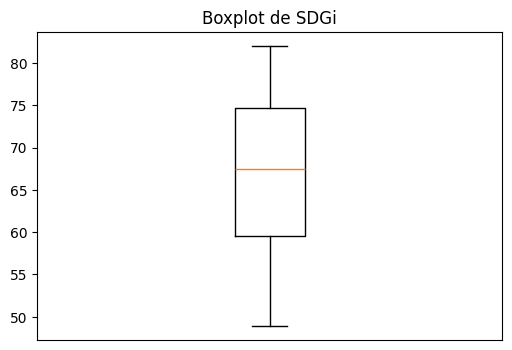

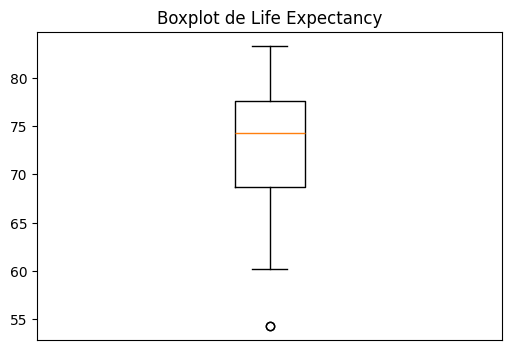

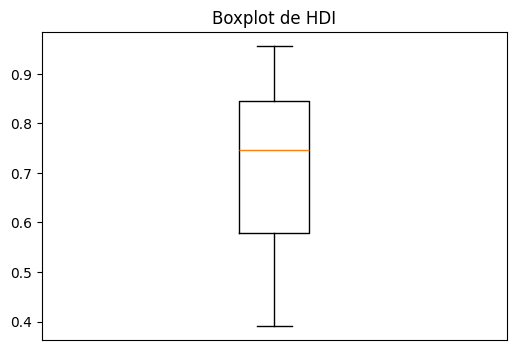

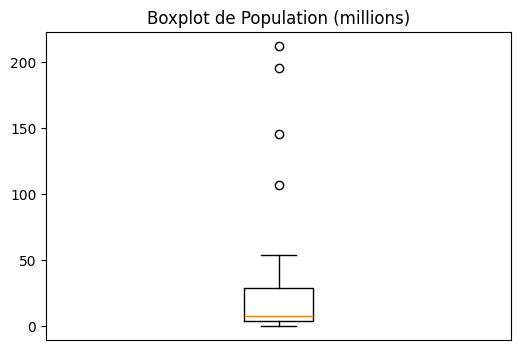

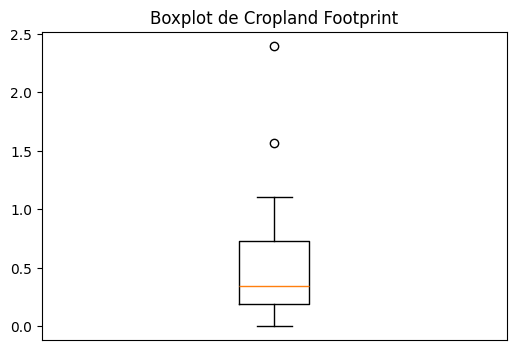

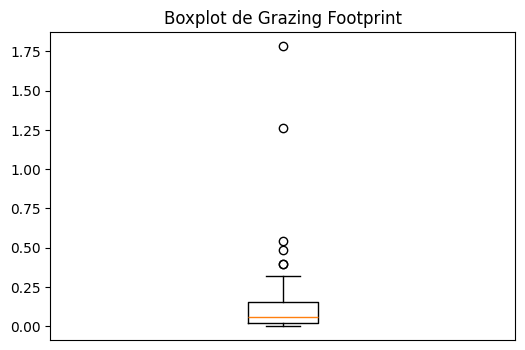

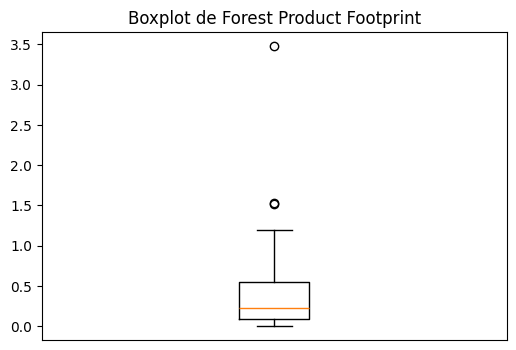

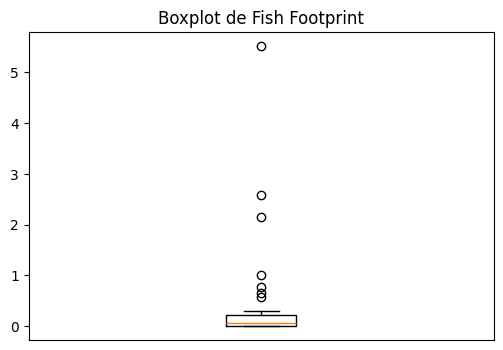

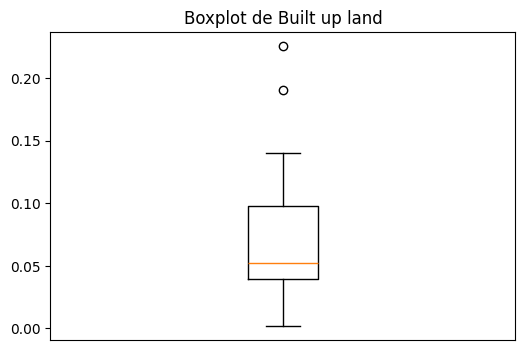

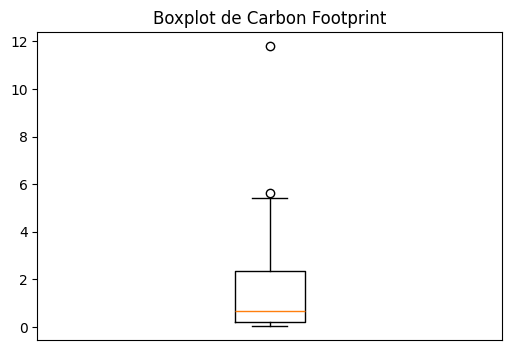

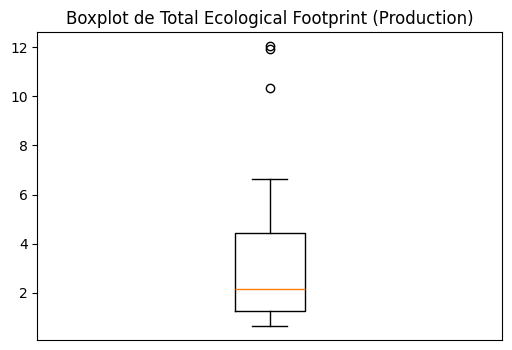

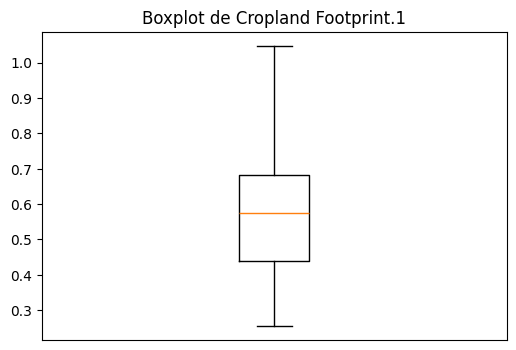

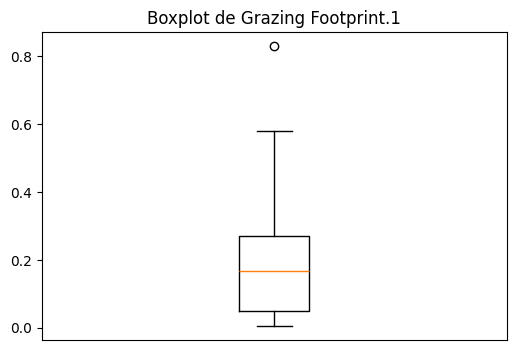

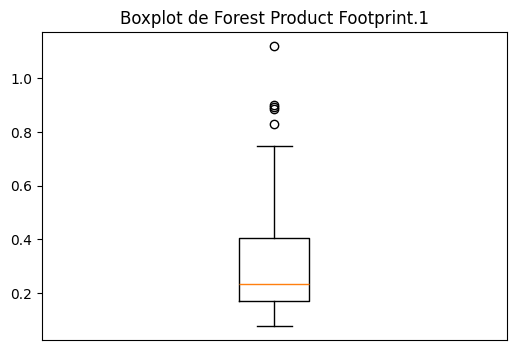

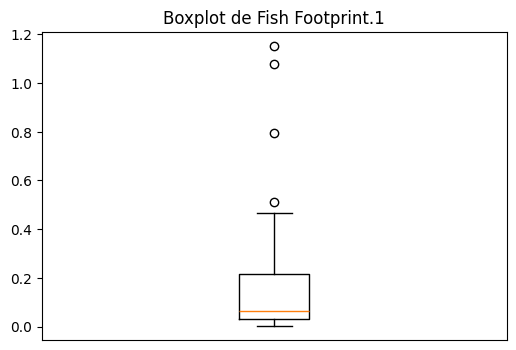

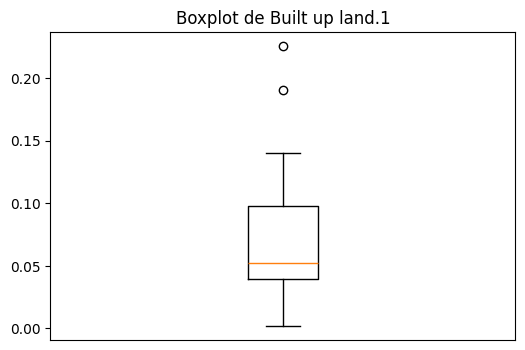

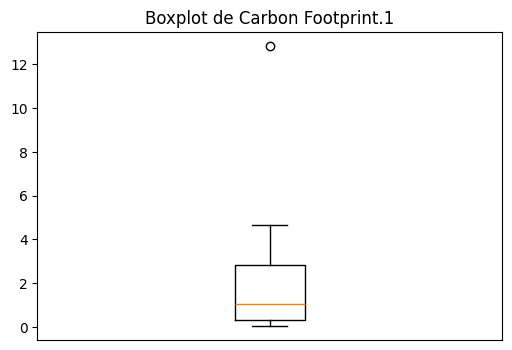

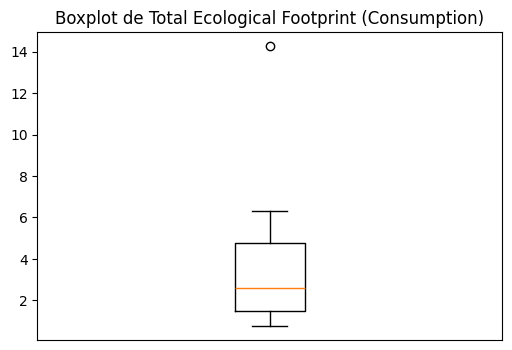

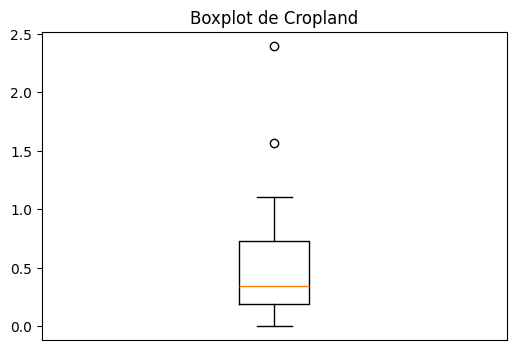

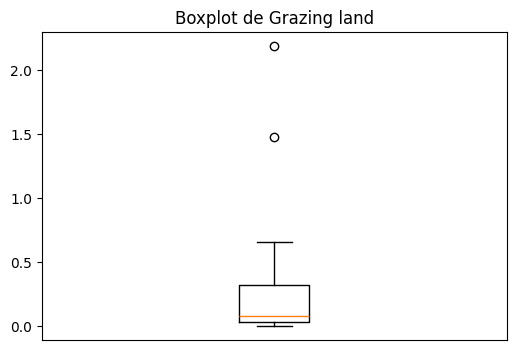

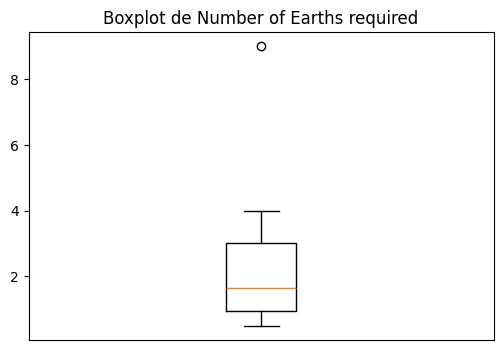

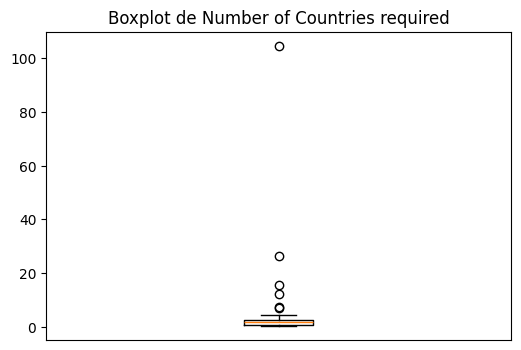

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Liste des variables explicatives
colonnes = ['SDGi', 'Life Expectancy', 'HDI', 'Population (millions)', 
                           'Cropland Footprint', 'Grazing Footprint', 'Forest Product Footprint', 
                           'Fish Footprint','Built up land','Carbon Footprint',
                           'Total Ecological Footprint (Production)','Cropland Footprint.1',
                           'Grazing Footprint.1','Forest Product Footprint.1','Fish Footprint.1',
                           'Built up land.1','Carbon Footprint.1','Total Ecological Footprint (Consumption)',
                           'Cropland','Grazing land','Number of Earths required','Number of Countries required']

### Boxplot pour chacune des variables explicatives

for col in colonnes:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_subset[col].dropna())
    plt.title(f"Boxplot de {col}")
    plt.xticks([])
    plt.show()

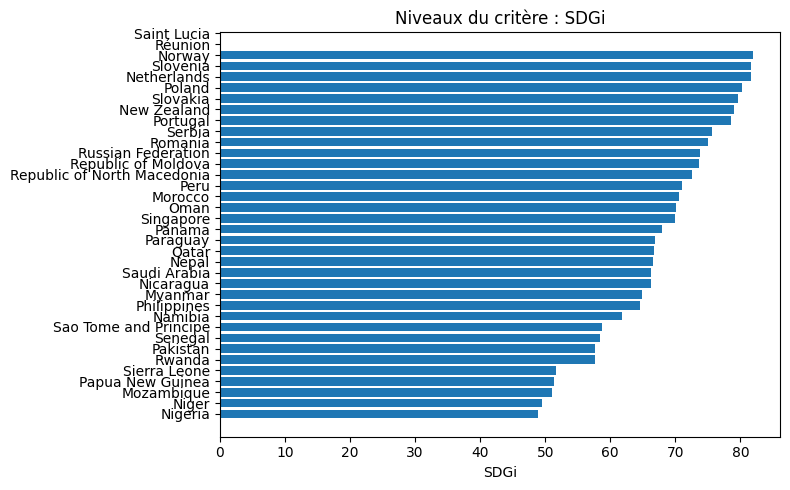

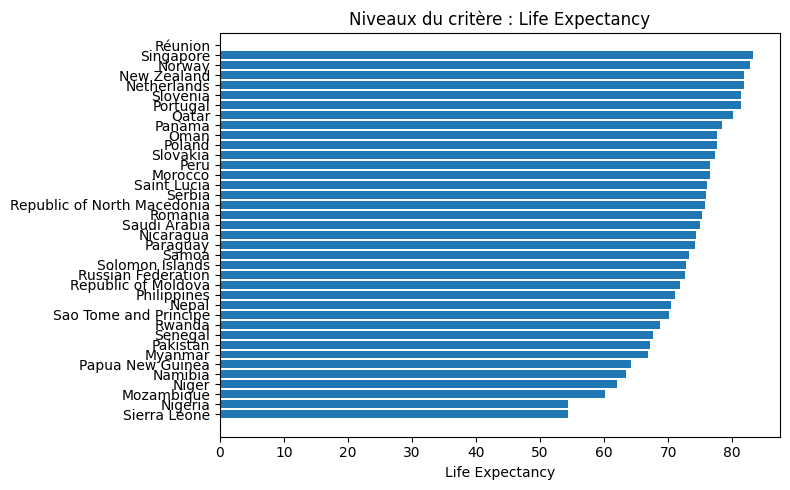

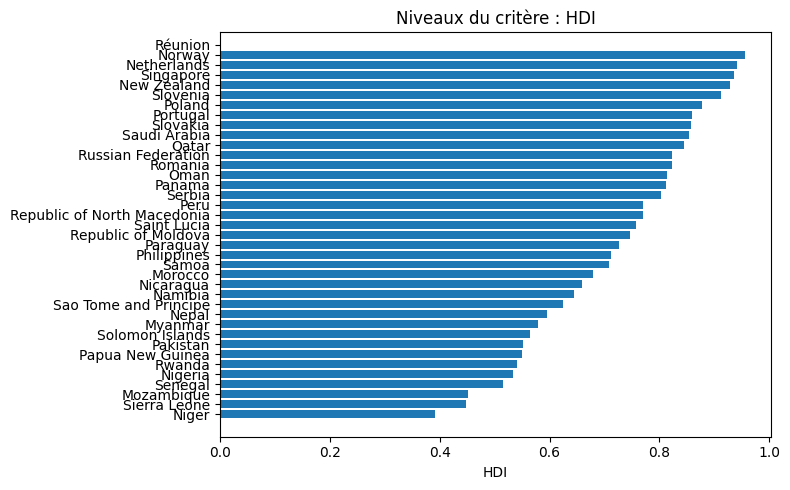

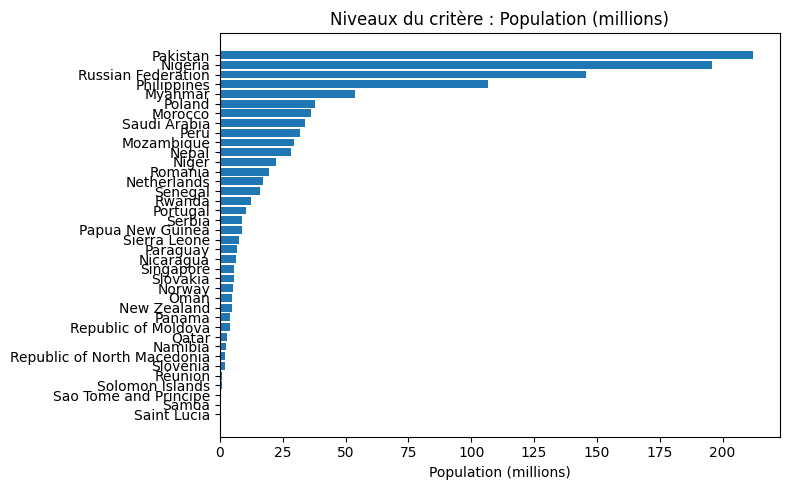

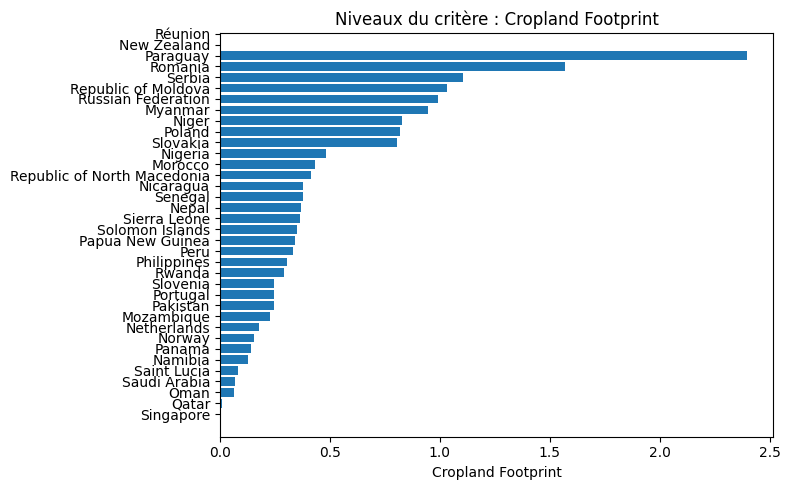

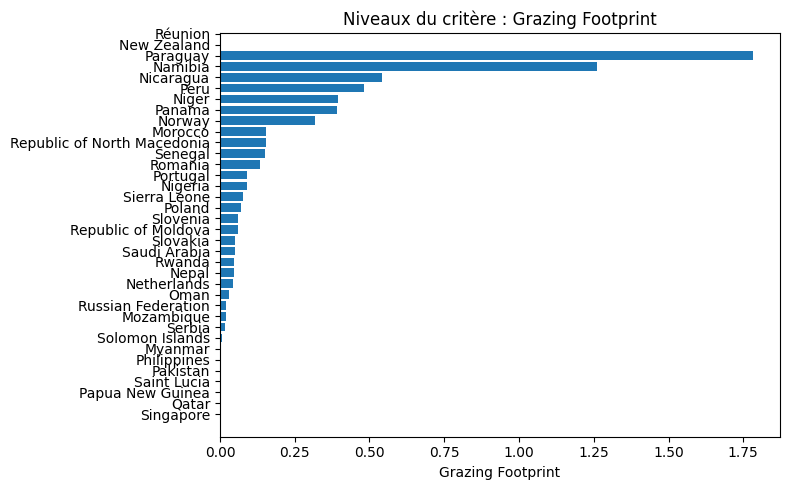

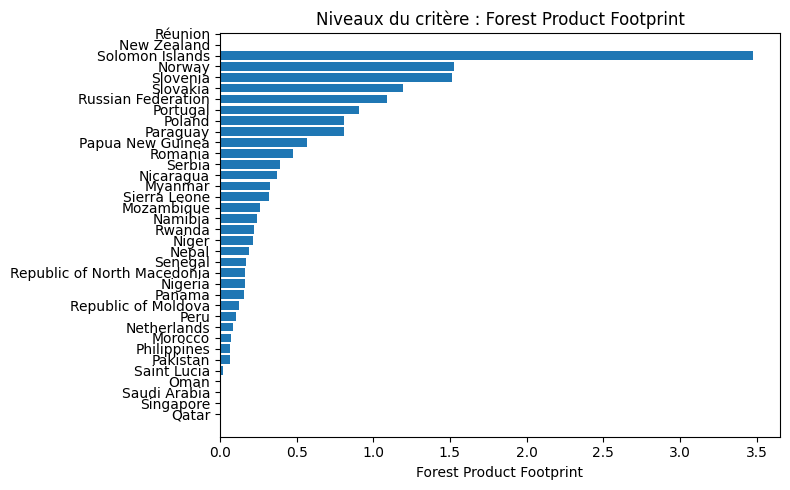

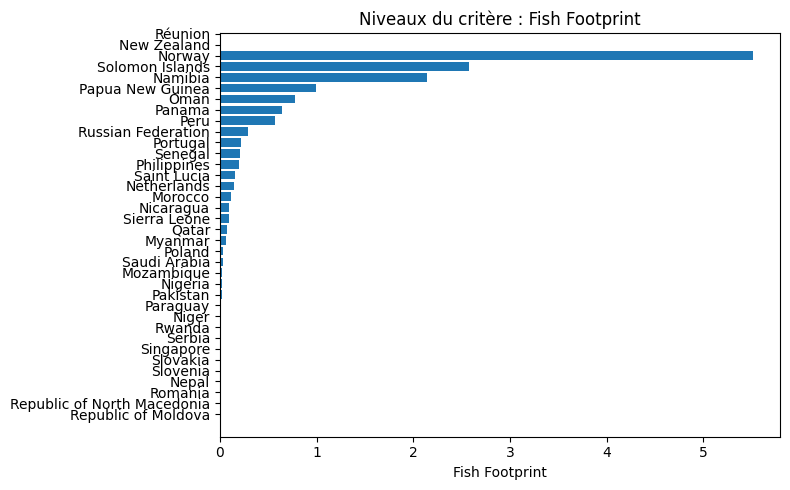

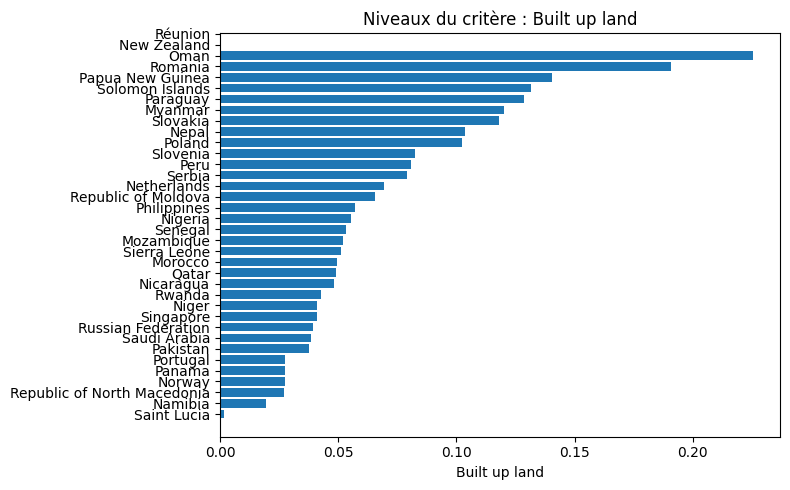

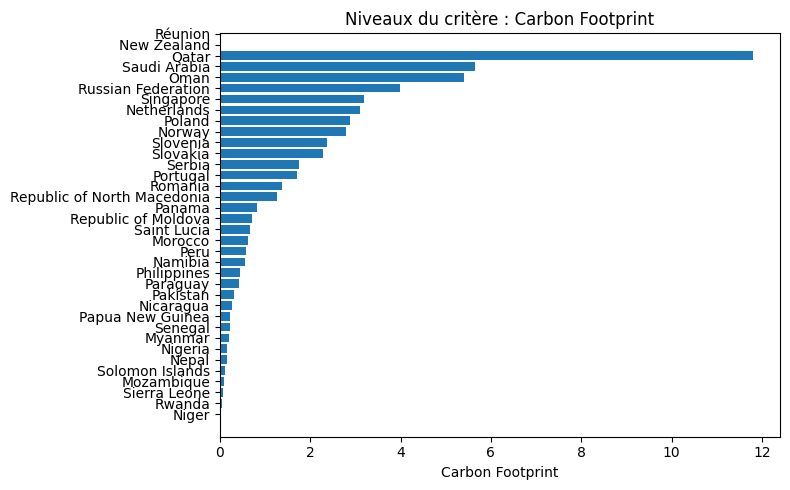

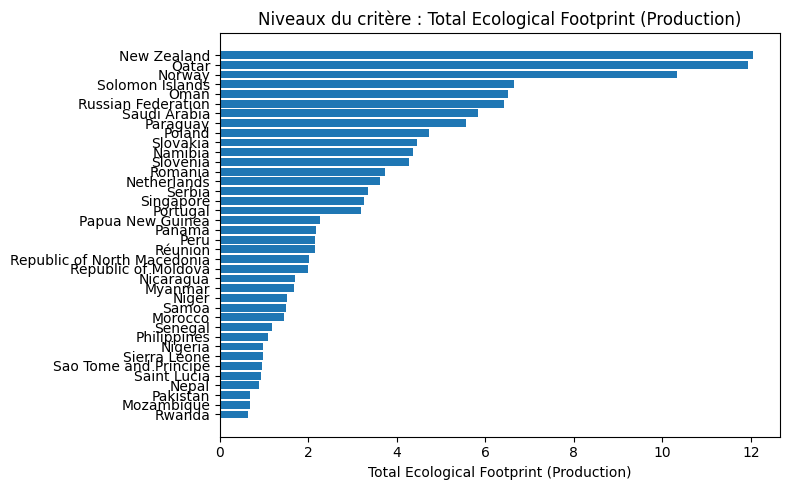

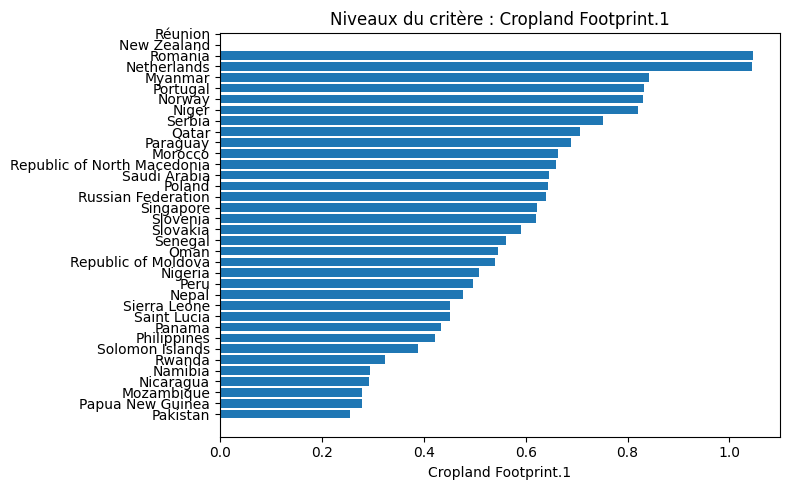

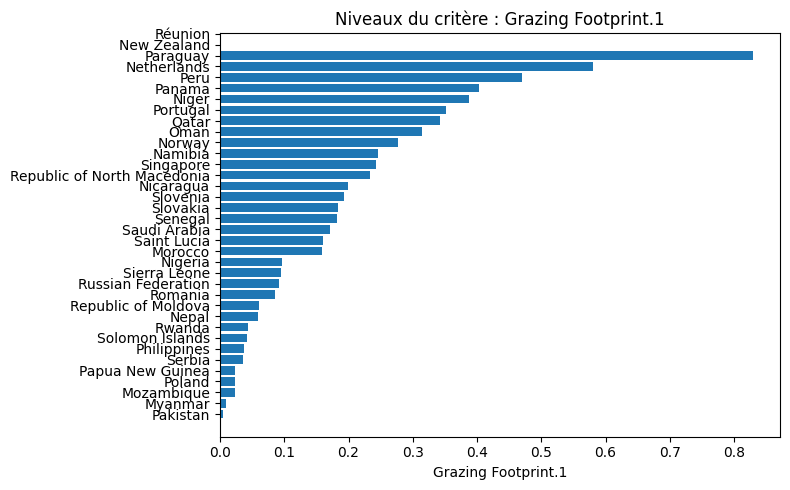

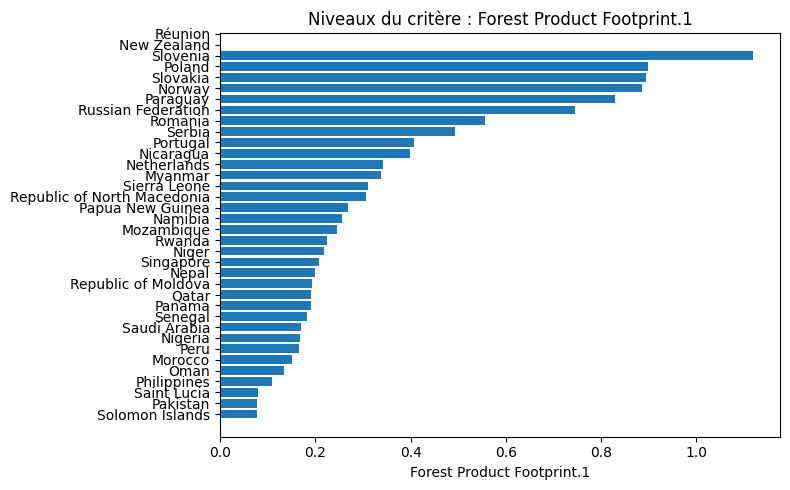

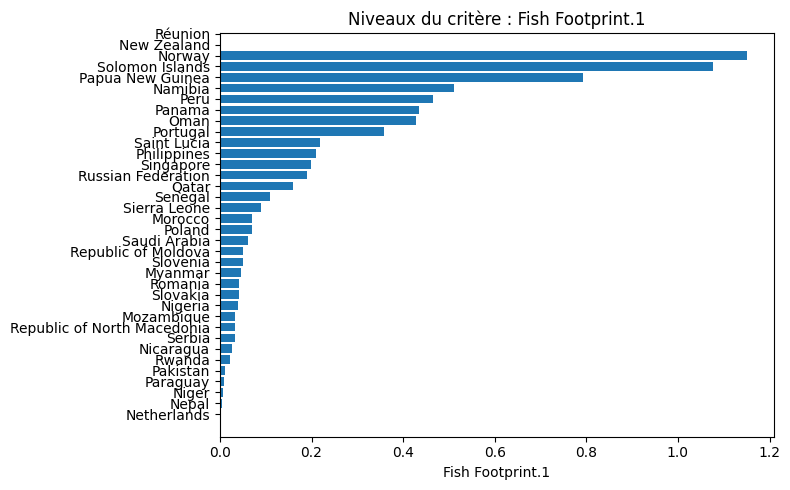

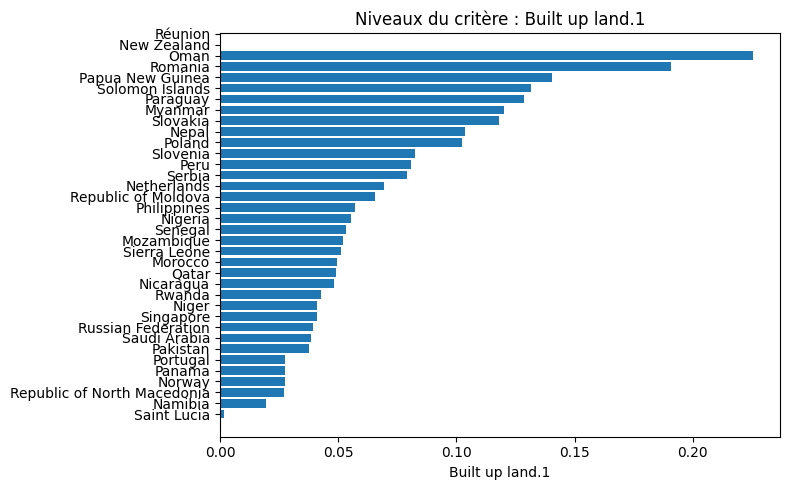

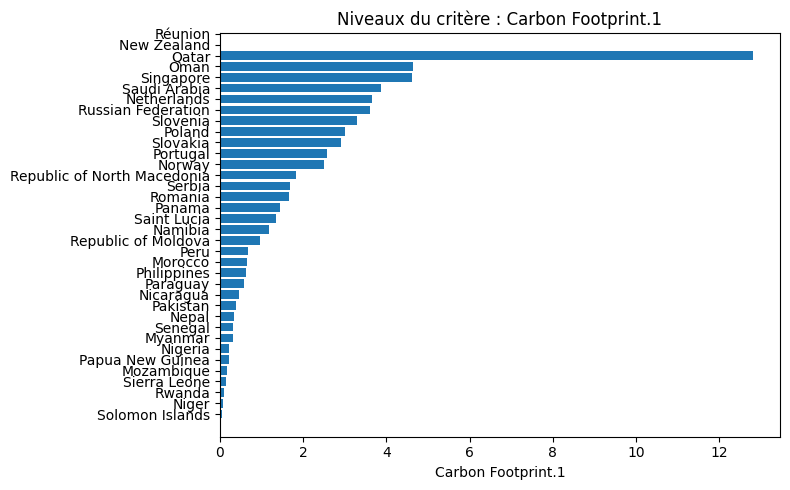

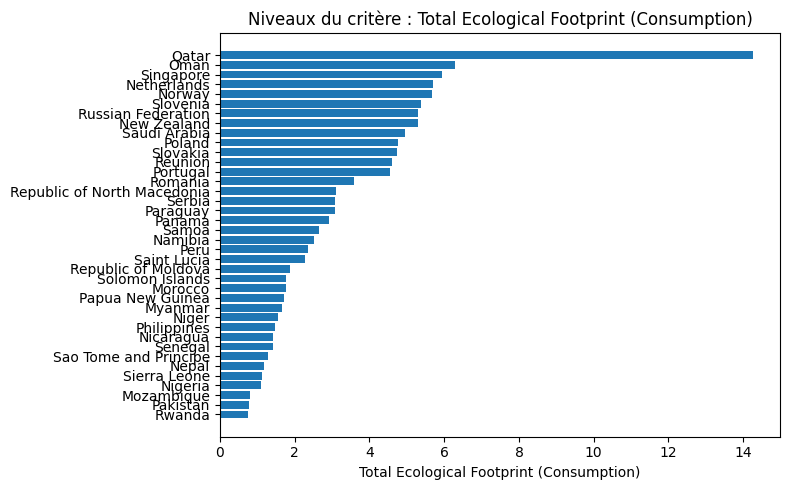

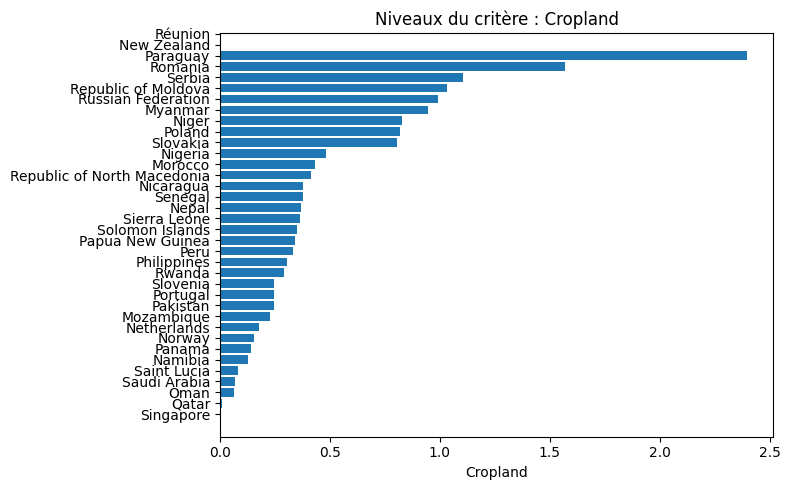

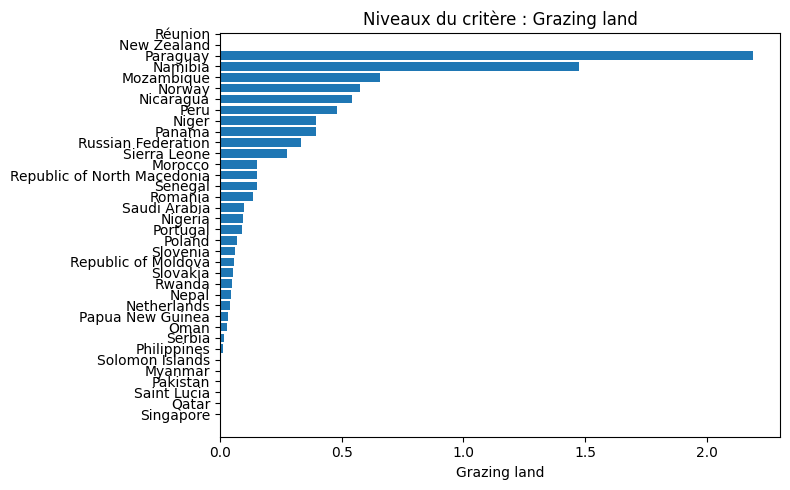

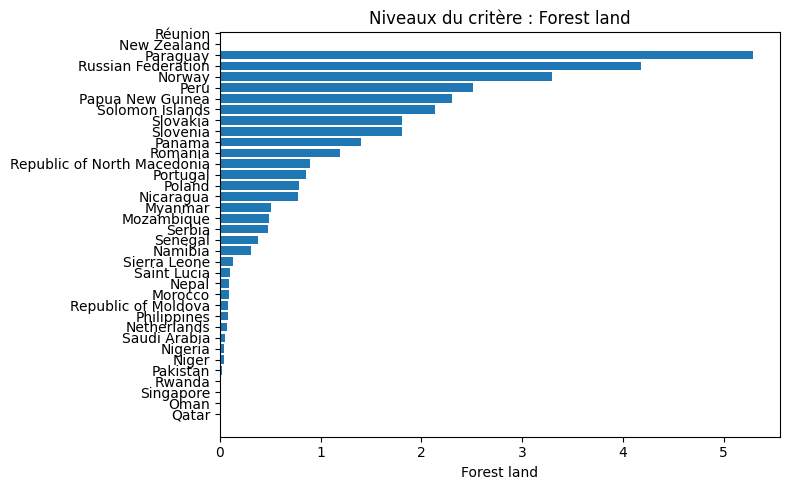

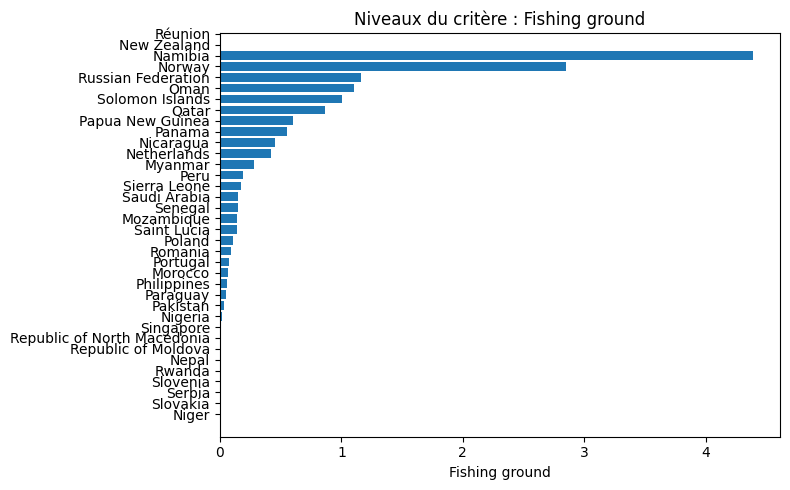

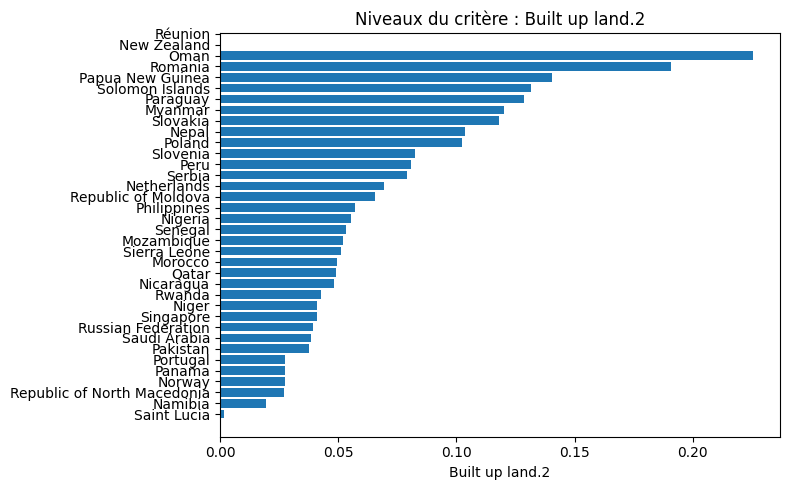

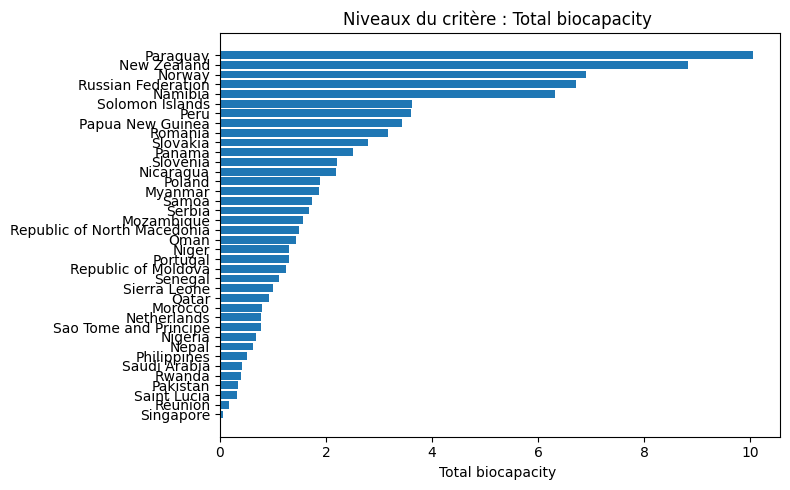

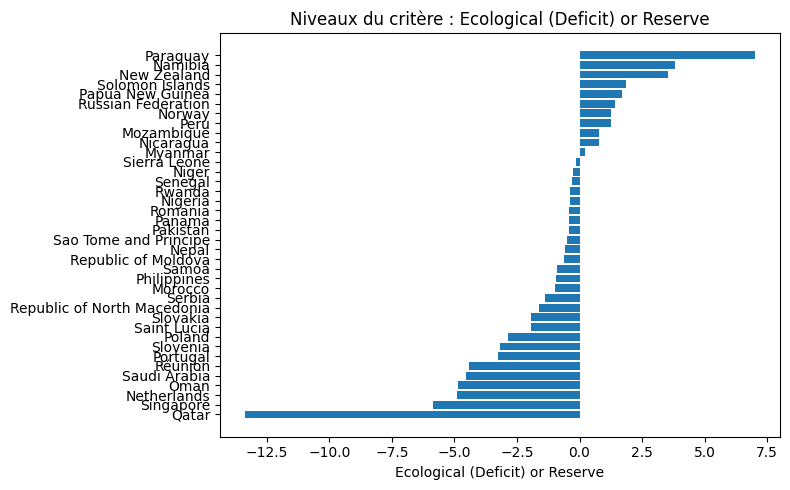

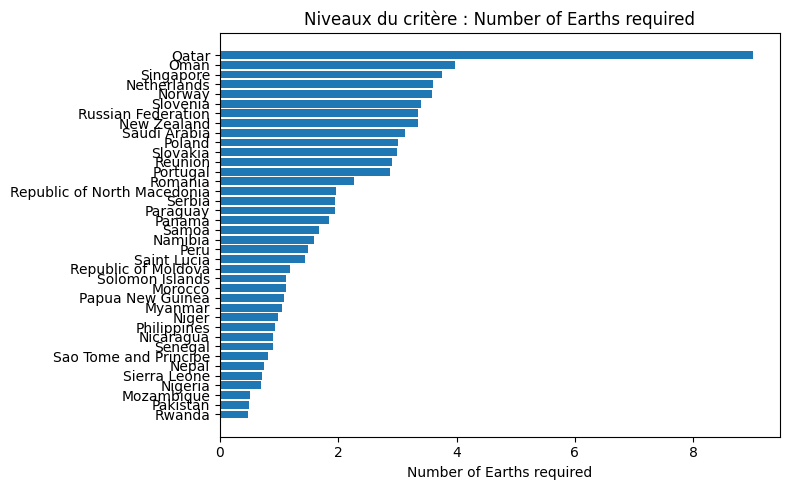

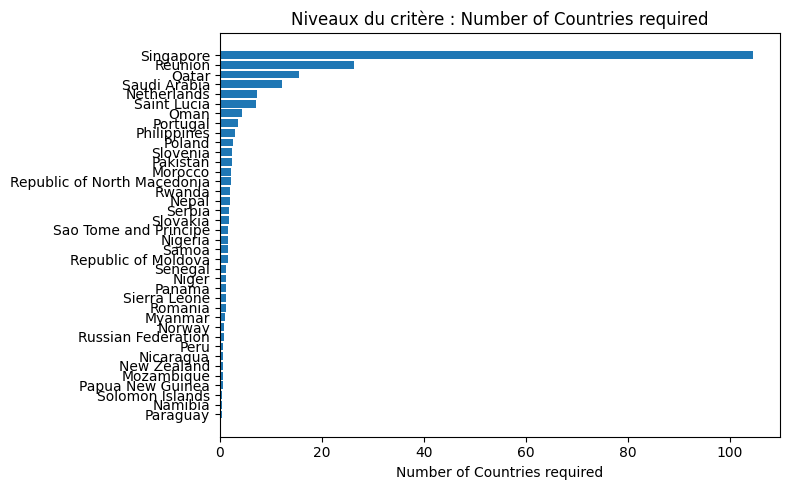

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

colonnes = df_subset.columns

for col in colonnes:
    # ignorer la colonne Pays ou les colonnes non numériques
    if col == "Country" or not pd.api.types.is_numeric_dtype(df_subset[col]):
        continue

    # Trier
    pays_classe = df_subset.sort_values(col)

    # Plot
    plt.figure(figsize=(8,5))
    plt.barh(pays_classe["Country"], pays_classe[col])
    plt.xlabel(col)
    plt.title(f"Niveaux du critère : {col}")
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Liste des variables explicatives
colonnes = ['SDGi', 'Life Expectancy', 'HDI', 'Population (millions)', 
                           'Cropland Footprint', 'Grazing Footprint', 'Forest Product Footprint', 
                           'Fish Footprint','Built up land','Carbon Footprint',
                           'Total Ecological Footprint (Production)','Cropland Footprint.1',
                           'Grazing Footprint.1','Forest Product Footprint.1','Fish Footprint.1',
                           'Built up land.1','Carbon Footprint.1','Total Ecological Footprint (Consumption)',
                           'Cropland','Grazing land','Number of Earths required','Number of Countries required']

### Boxplot pour chacune des variables explicatives

for col in colonnes:
    plt.figure(figsize=(6,4))
    plt.boxplot(df_subset[col].dropna())
    plt.title(f"Boxplot de {col}")
    plt.xticks([])
    plt.show()

# Pour tout le tableau

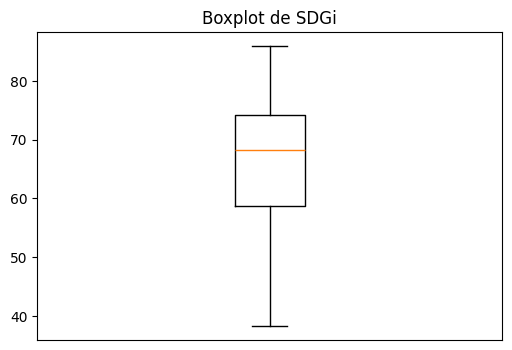

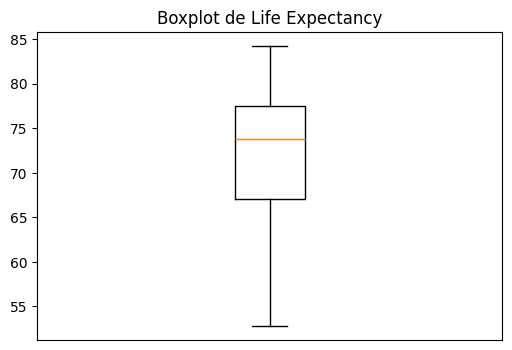

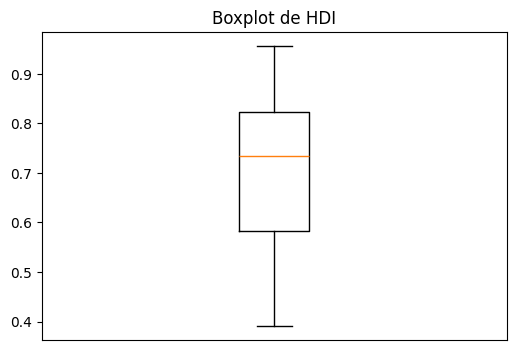

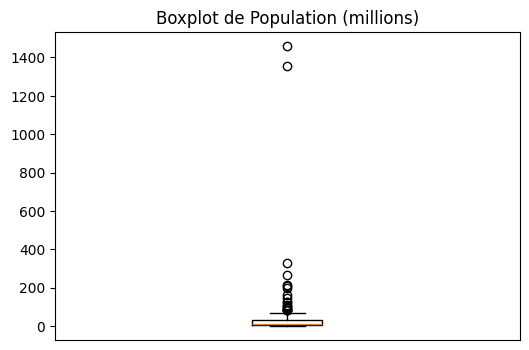

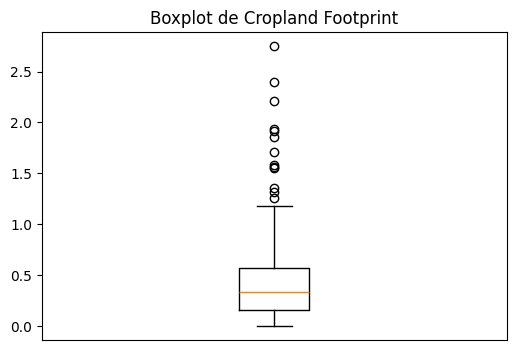

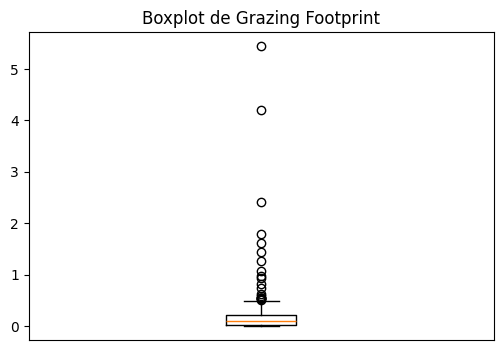

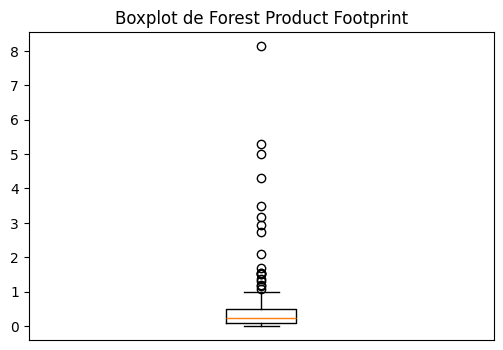

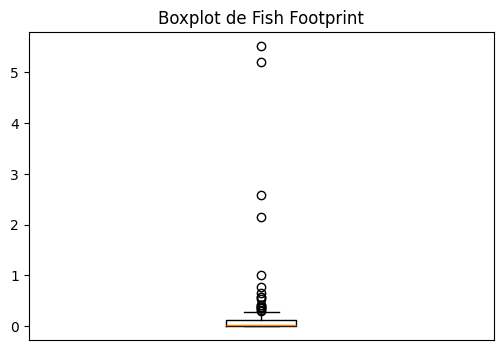

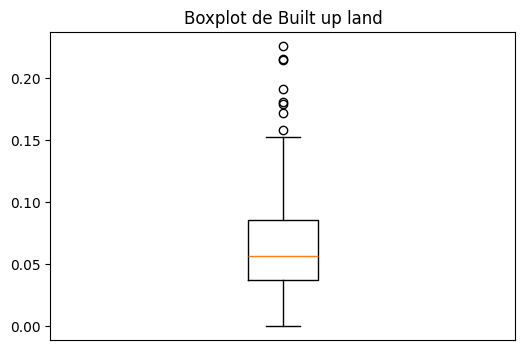

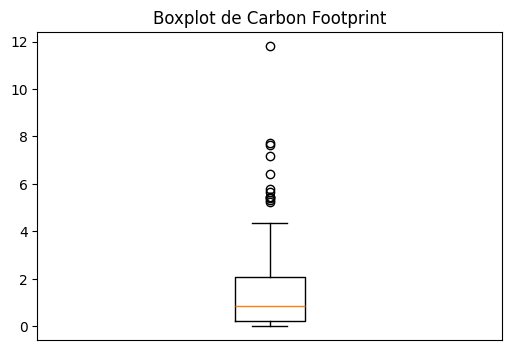

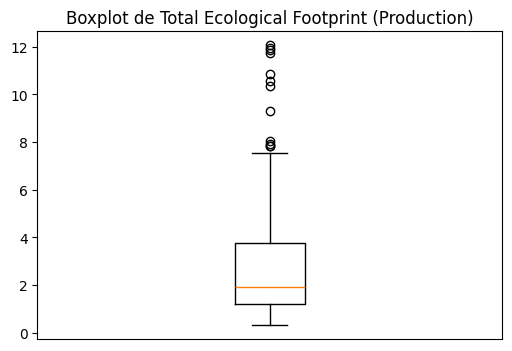

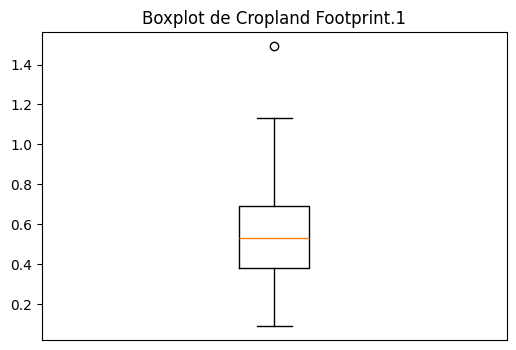

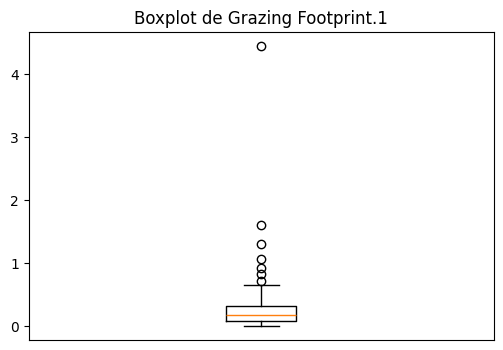

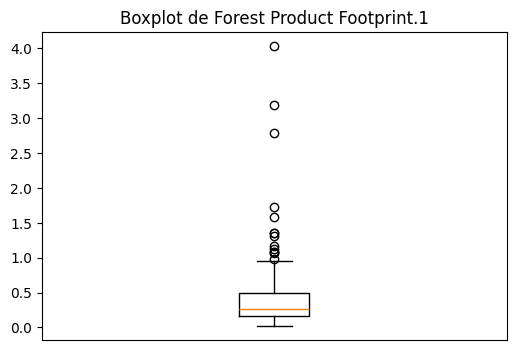

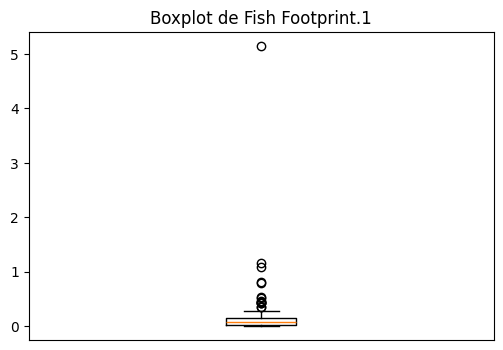

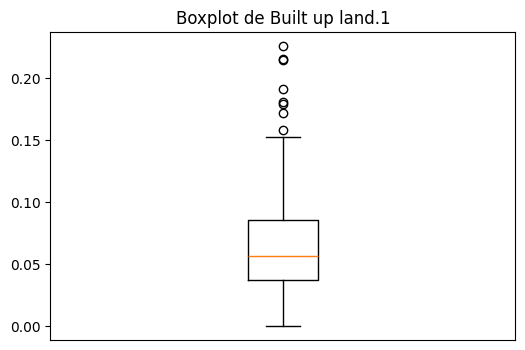

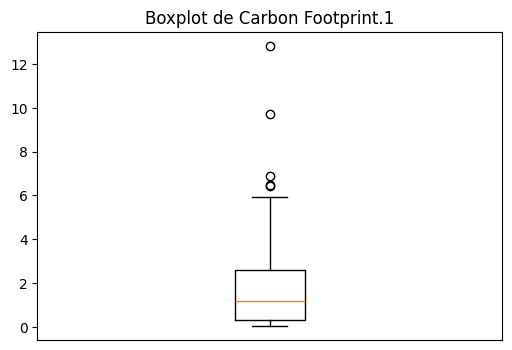

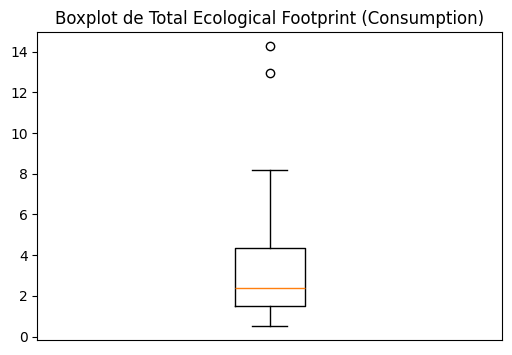

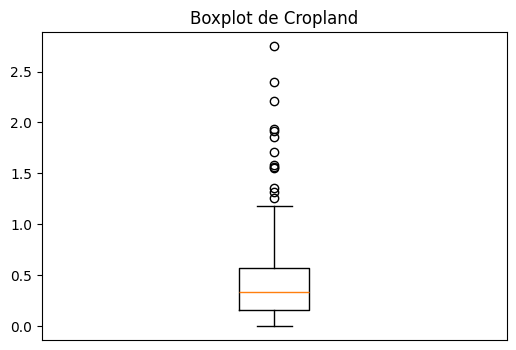

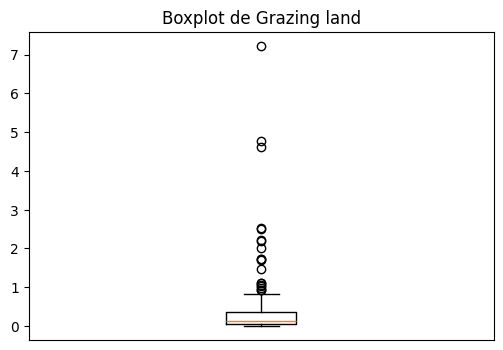

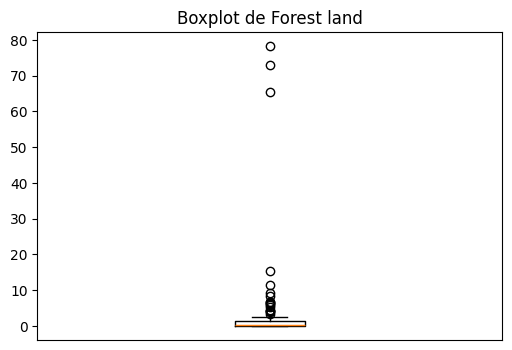

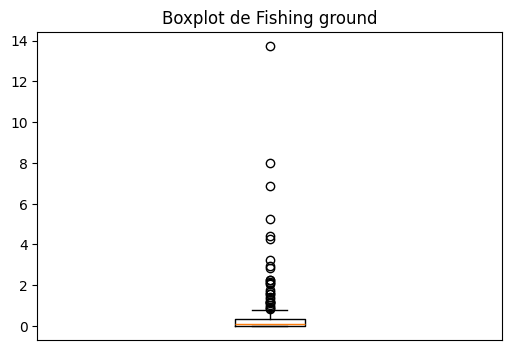

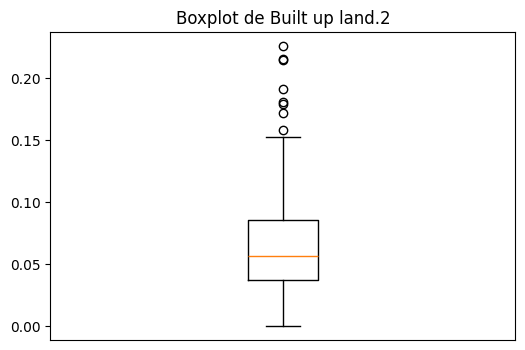

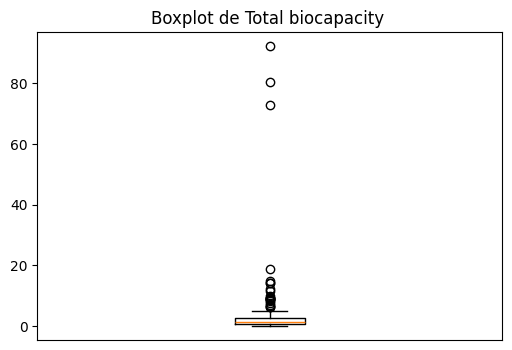

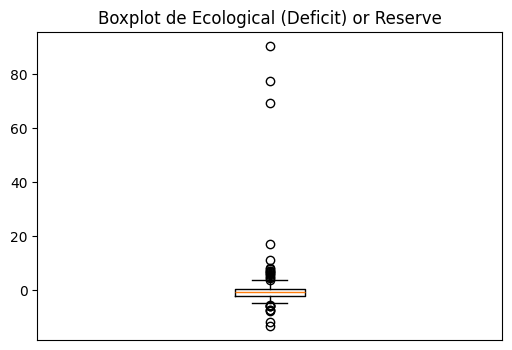

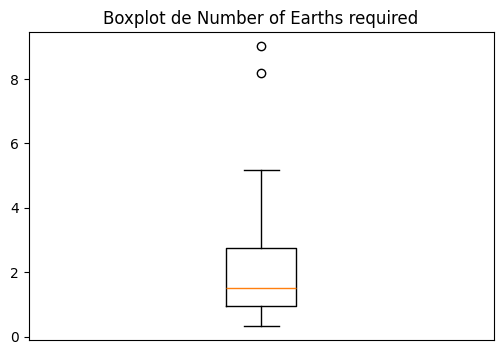

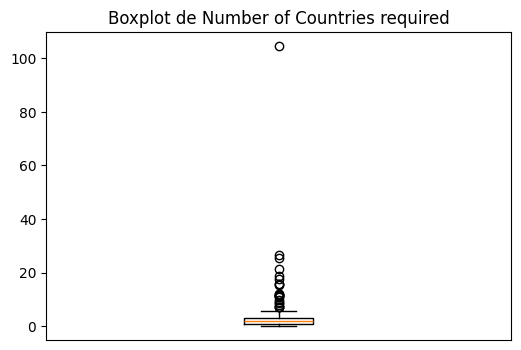

In [4]:
import matplotlib.pyplot as plt

# Sélection des colonnes numériques
colonnes_numeriques = df.select_dtypes(include='number').columns

for col in colonnes_numeriques:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot de {col}")
    plt.xticks([])  # Pas de ticks sur l'axe X
    plt.show()


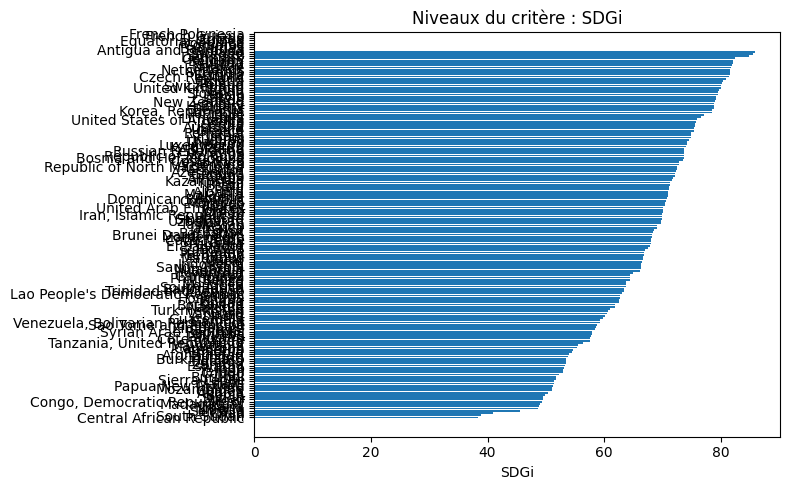

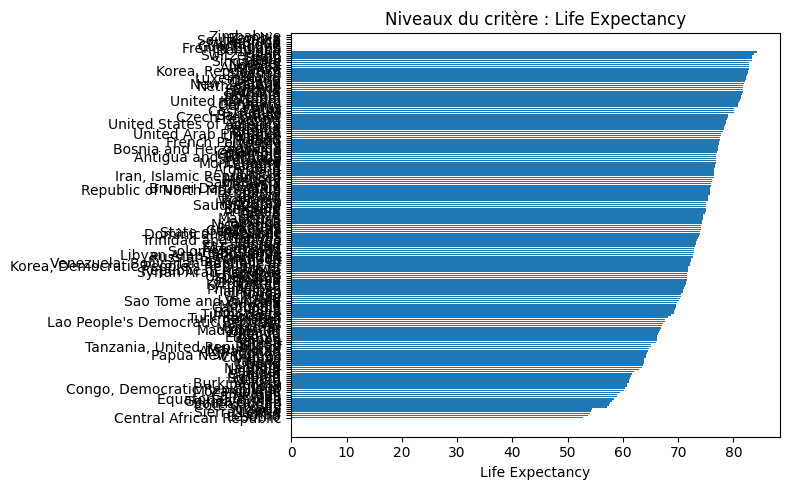

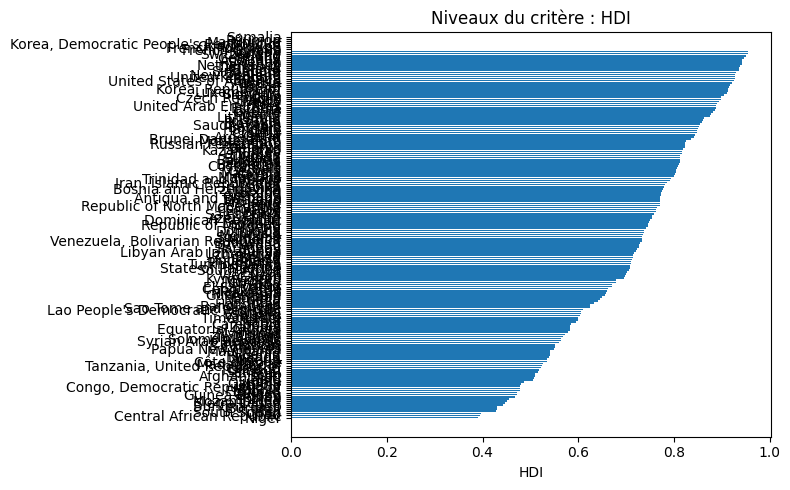

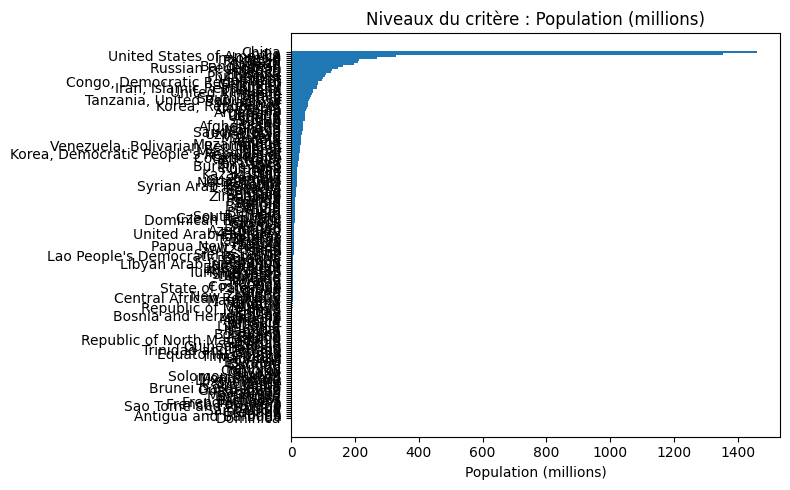

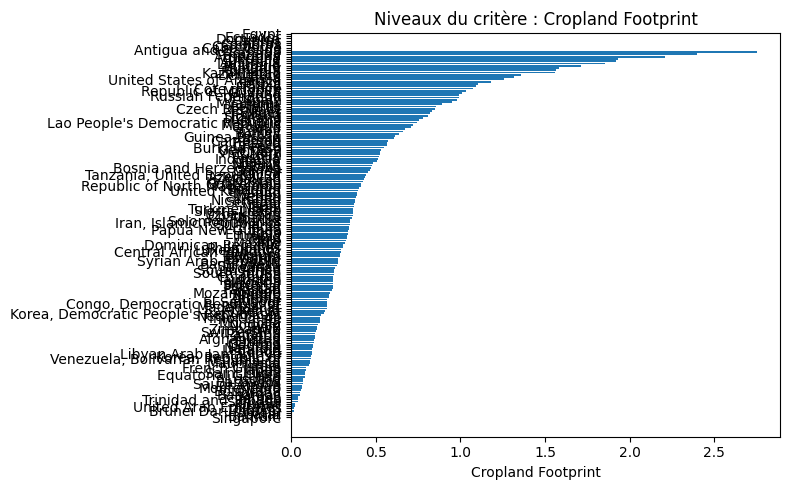

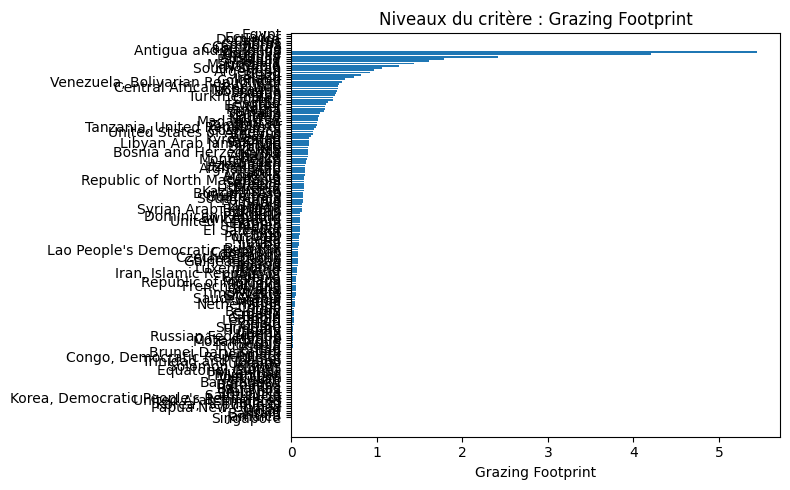

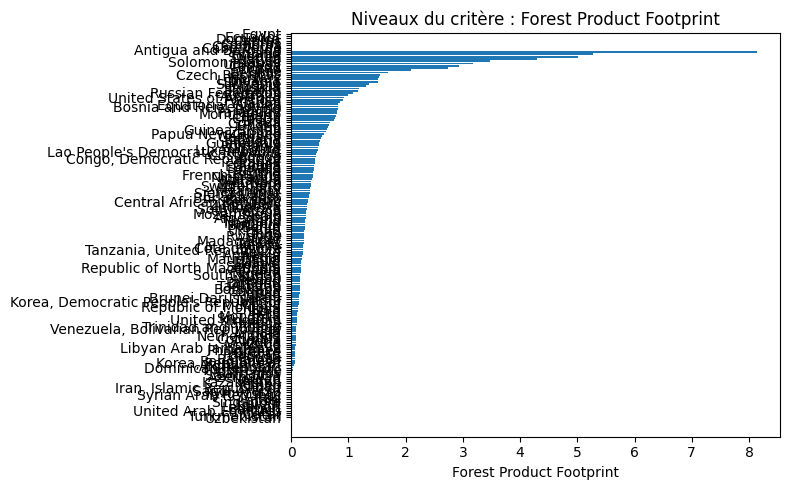

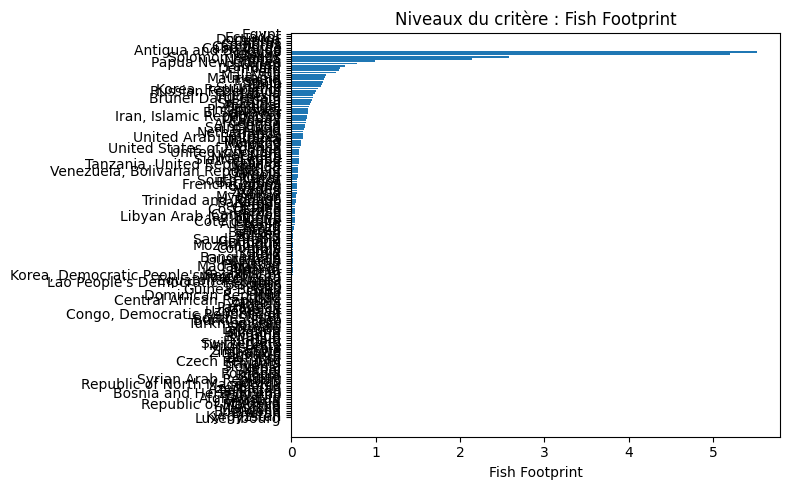

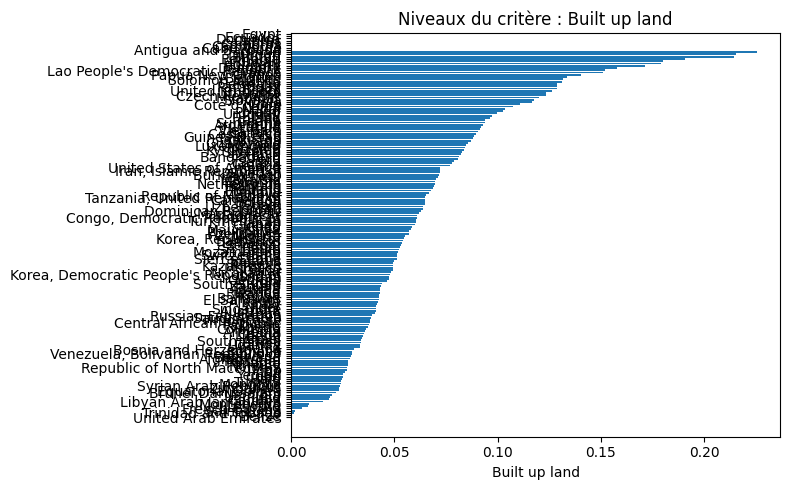

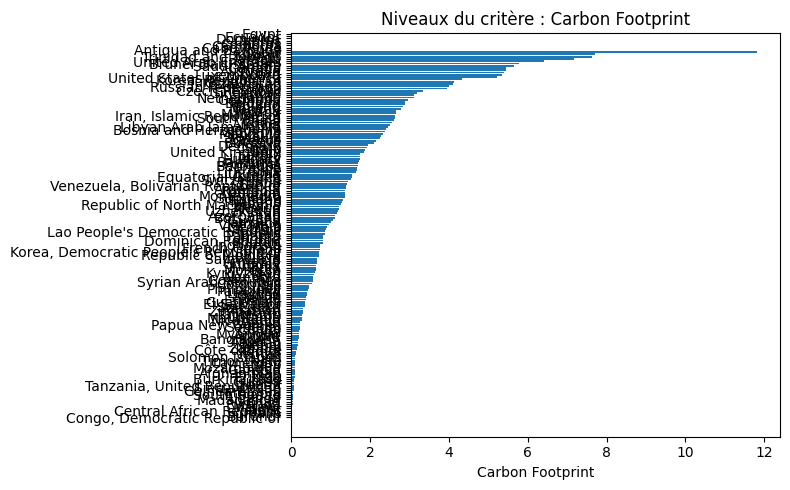

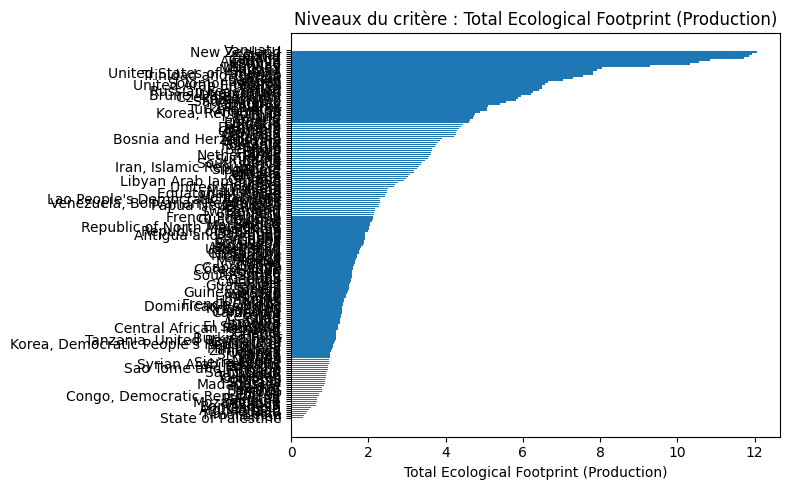

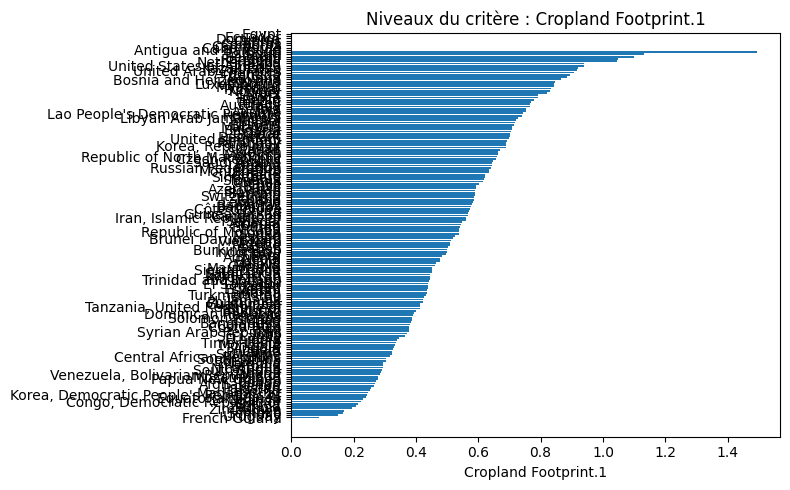

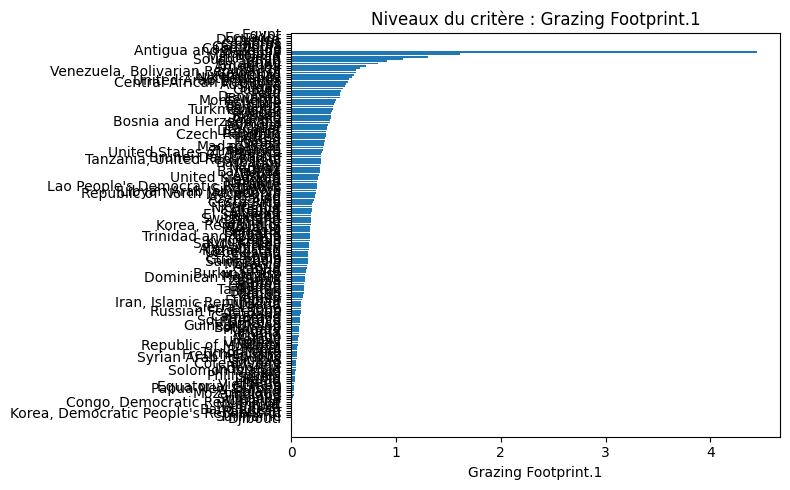

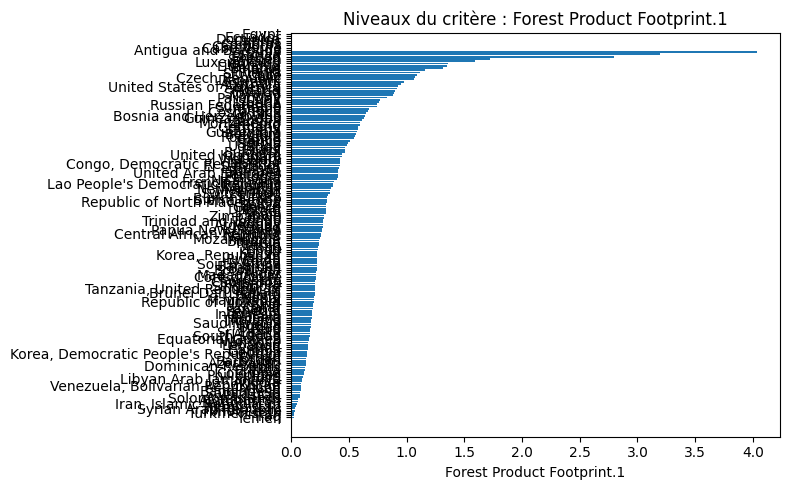

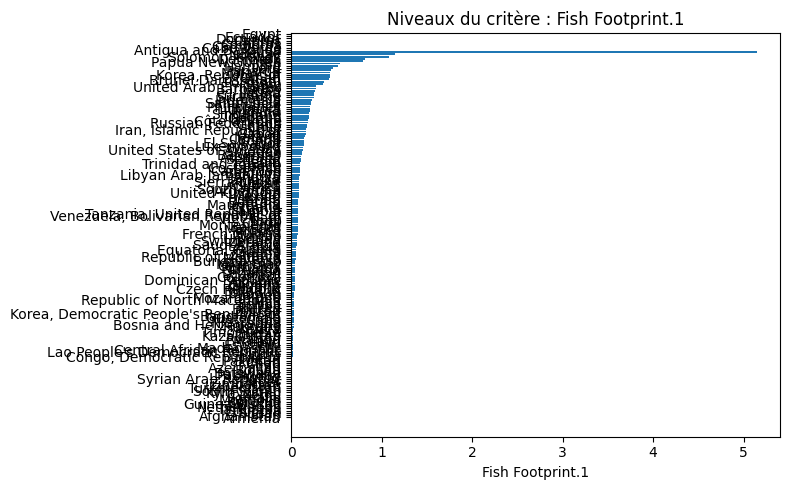

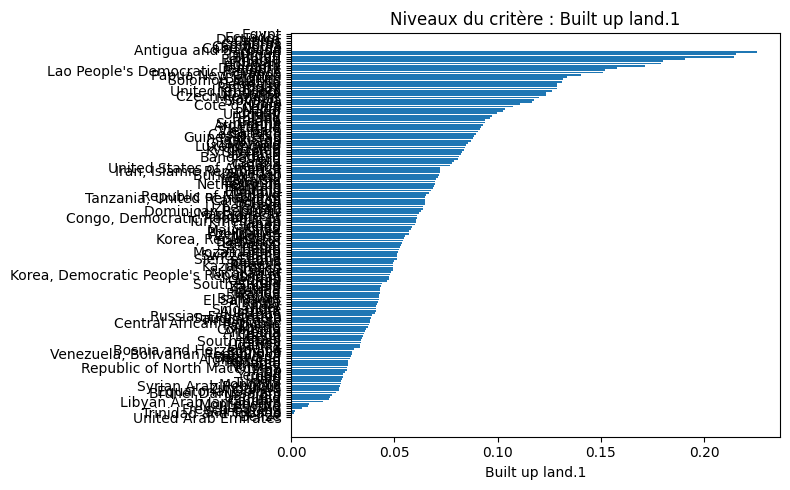

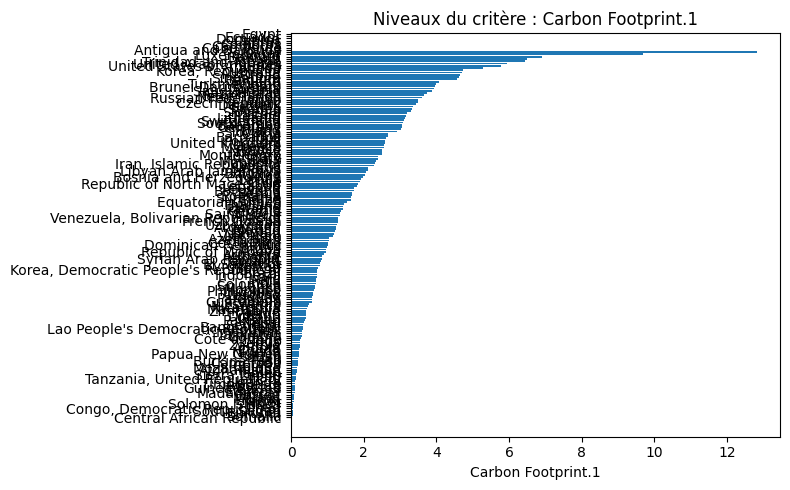

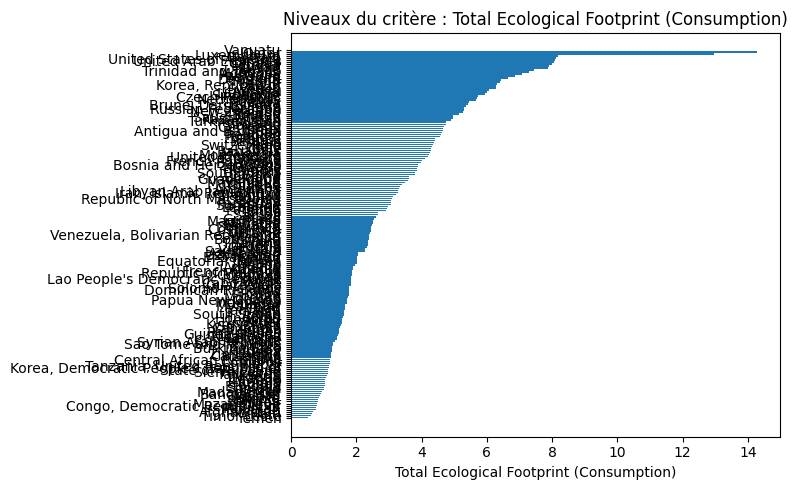

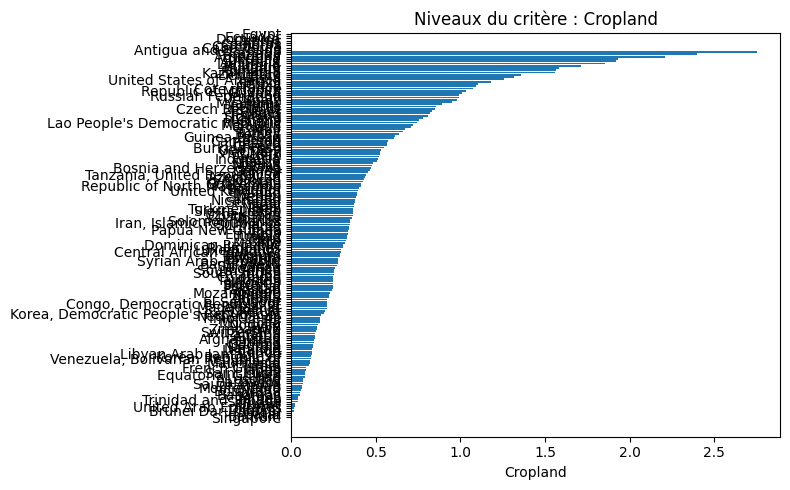

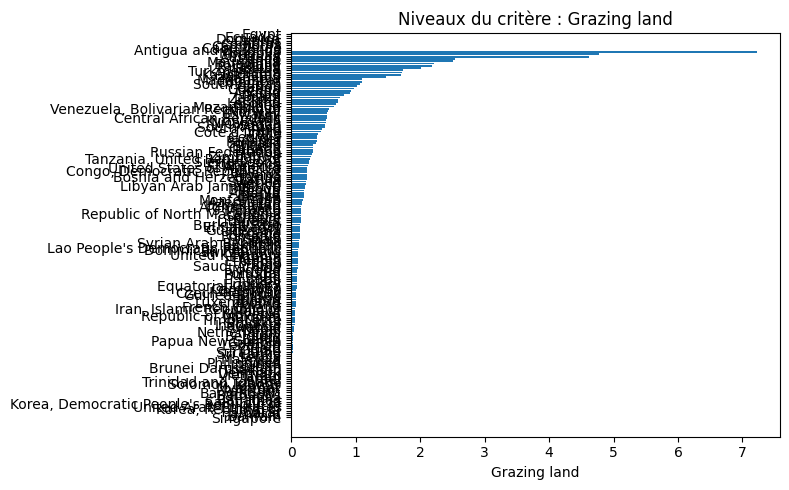

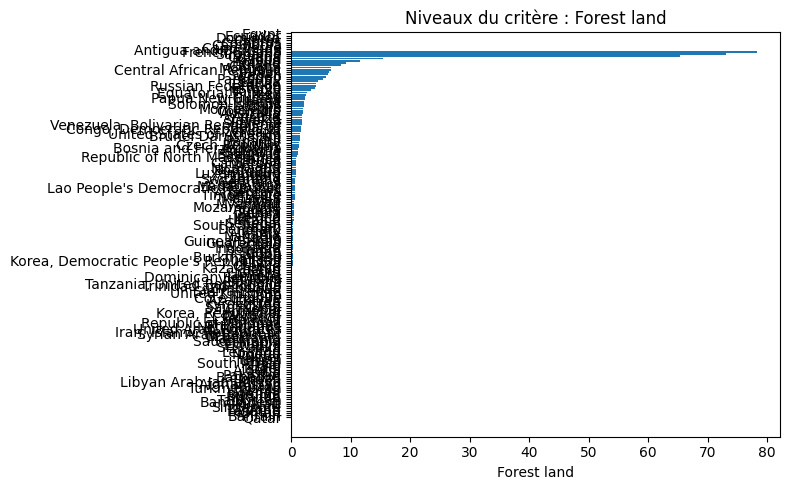

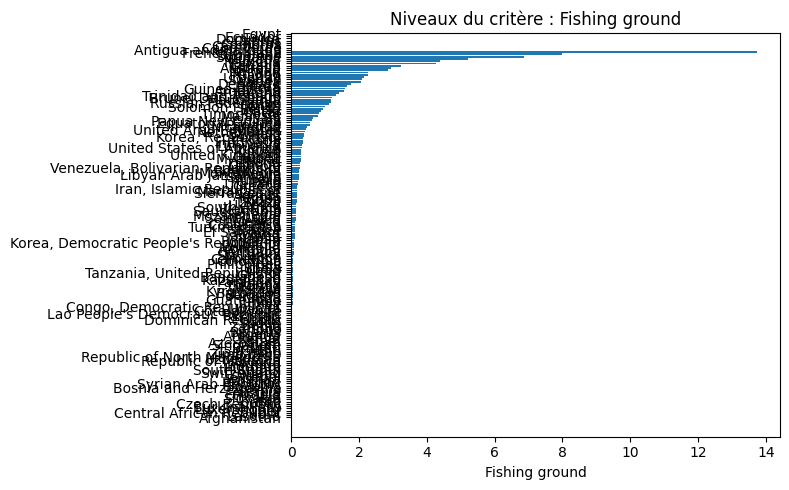

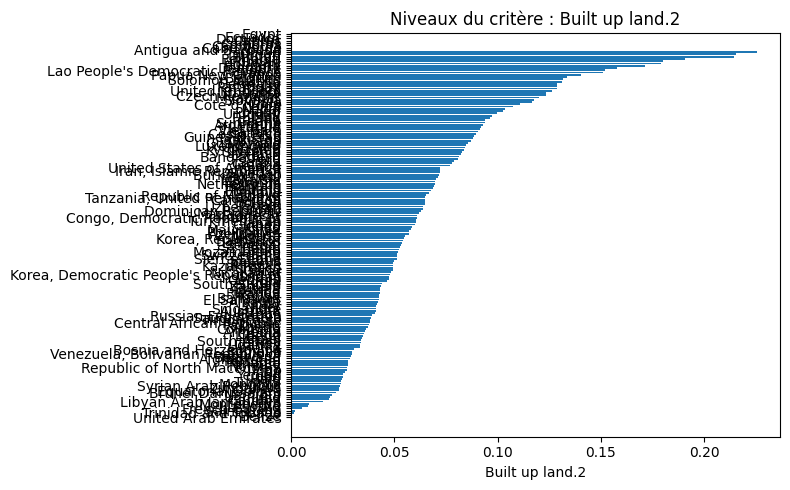

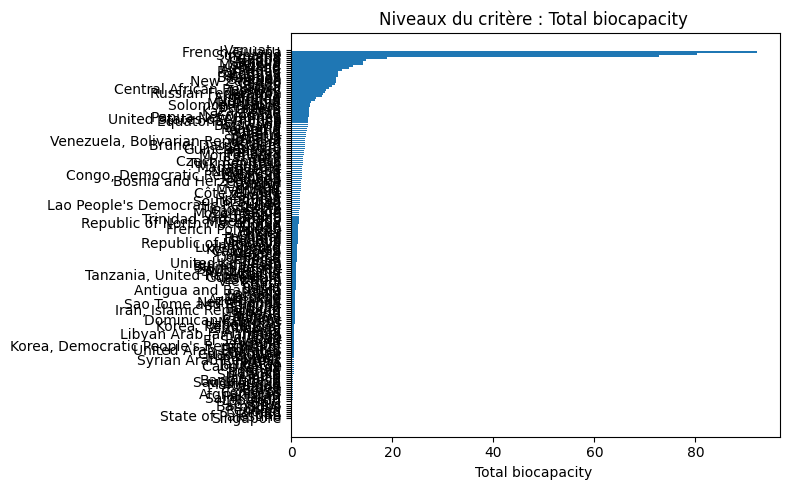

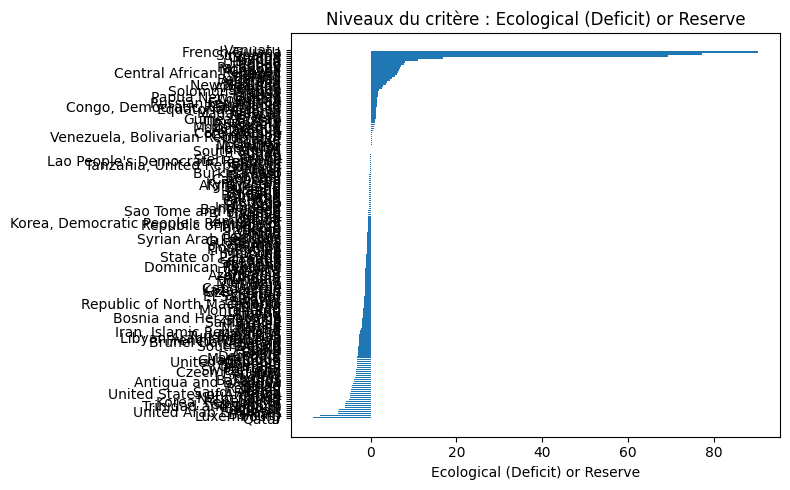

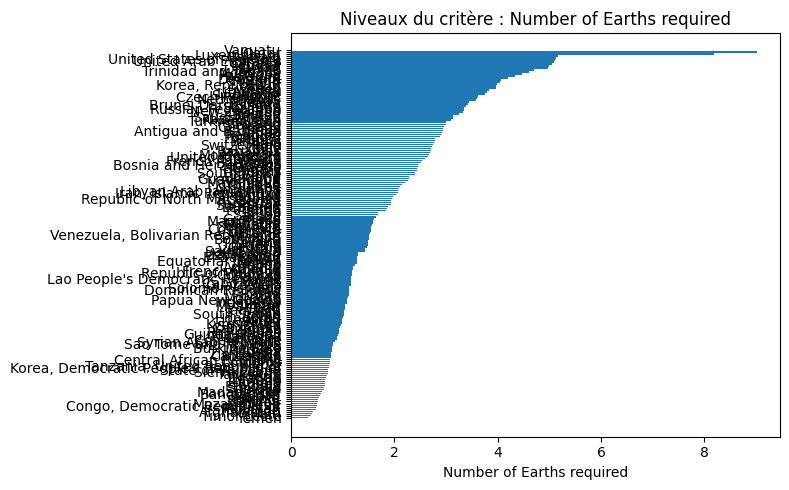

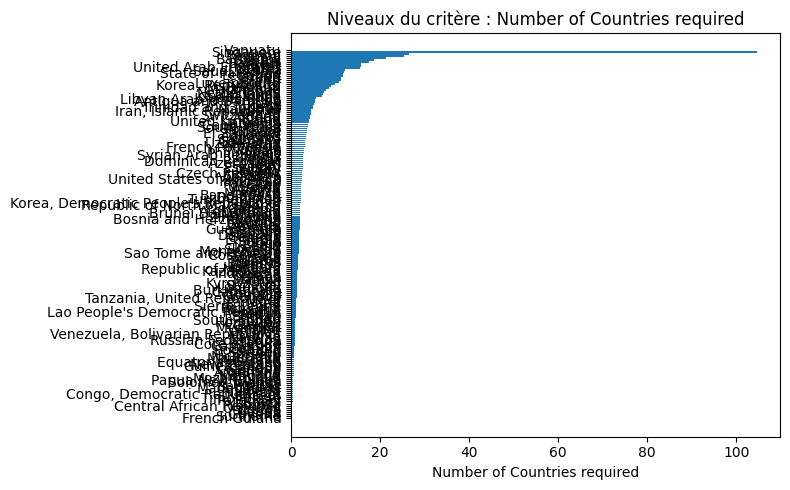

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

colonnes = df.columns

for col in colonnes:
    # ignorer la colonne Pays ou les colonnes non numériques
    if col == "Country" or not pd.api.types.is_numeric_dtype(df[col]):
        continue

    # Trier
    pays_classe = df.sort_values(col)

    # Plot
    plt.figure(figsize=(8,5))
    plt.barh(pays_classe["Country"], pays_classe[col])
    plt.xlabel(col)
    plt.title(f"Niveaux du critère : {col}")
    plt.tight_layout()
    plt.show()

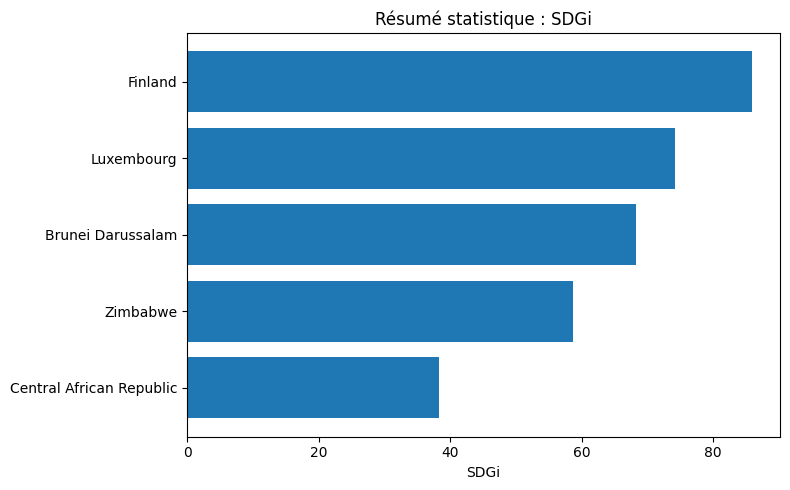

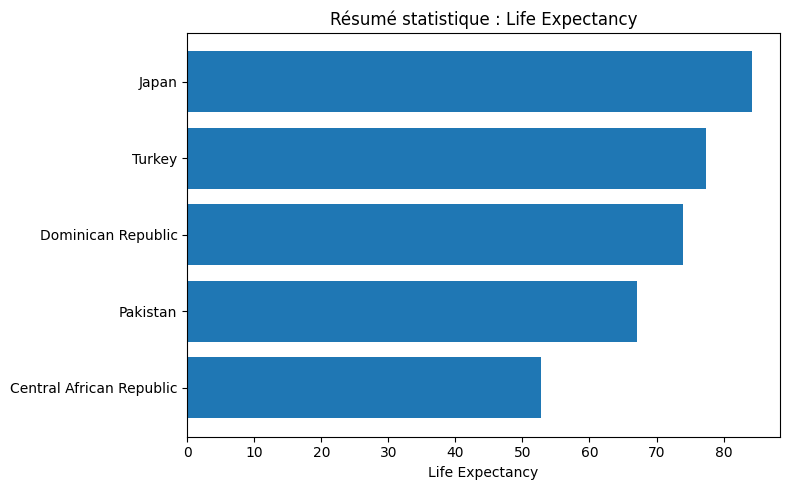

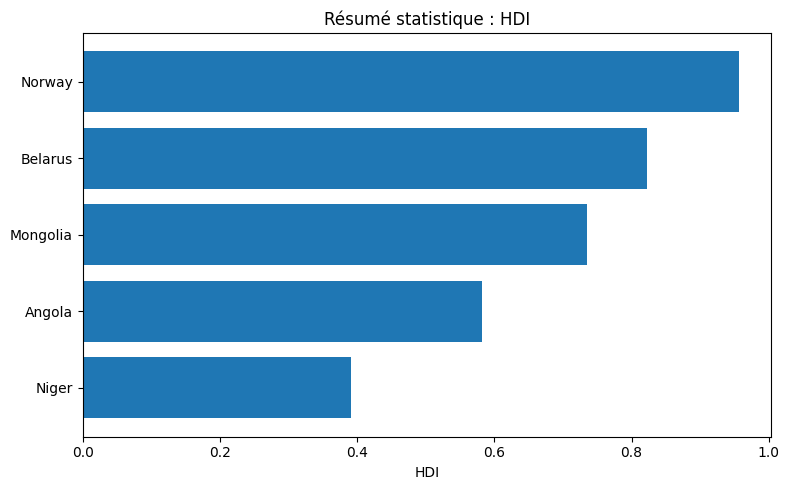

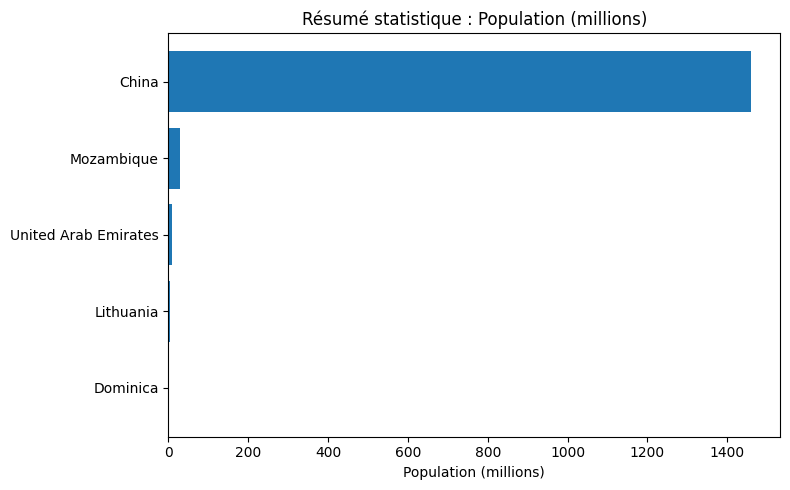

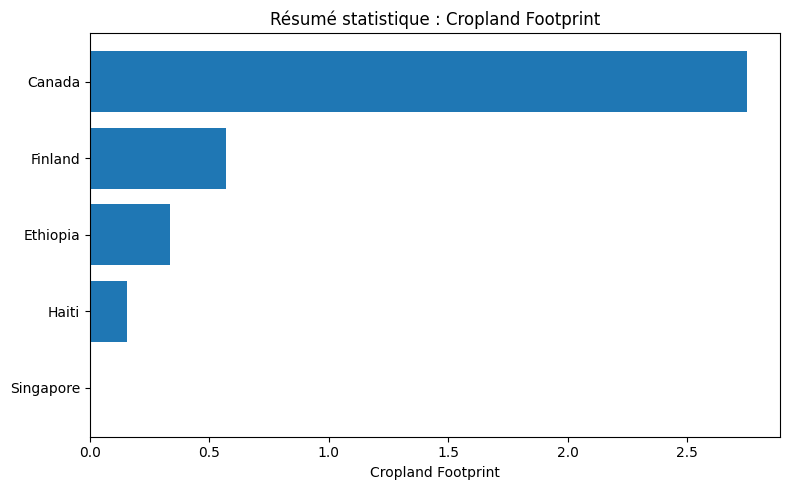

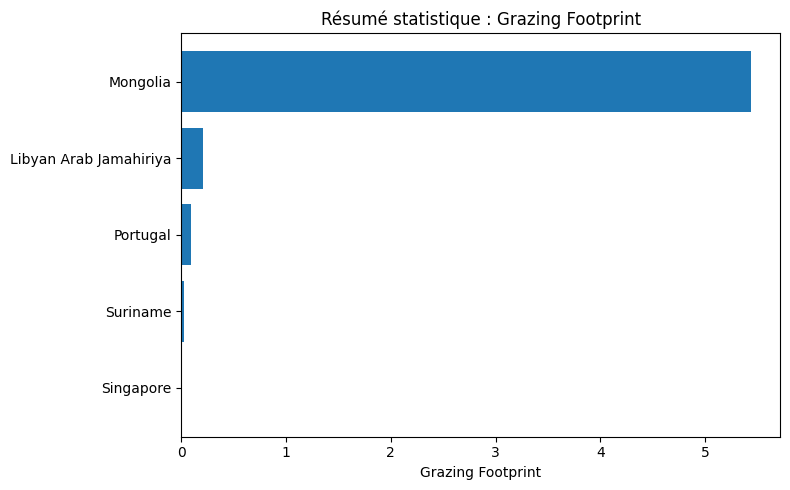

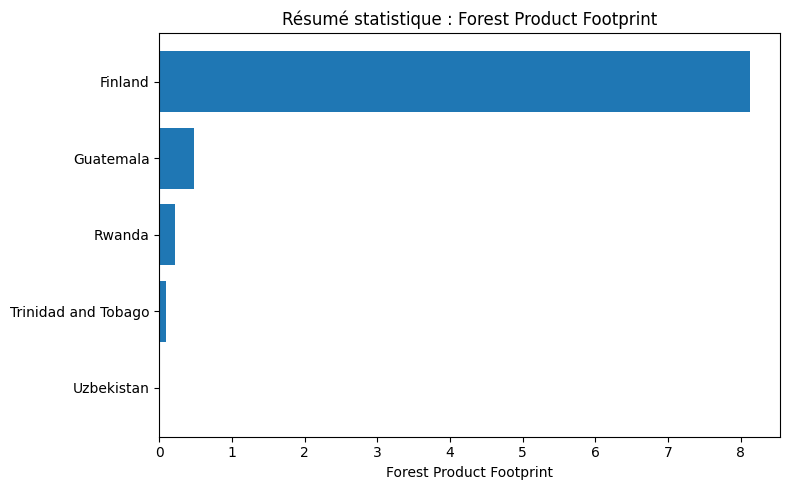

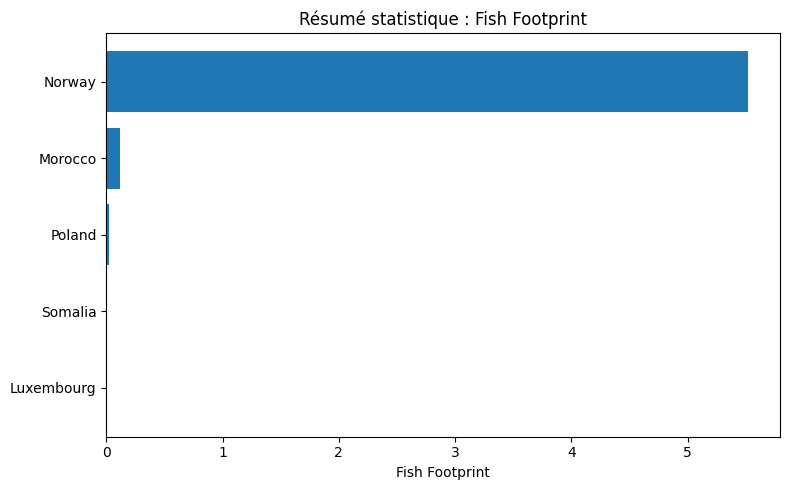

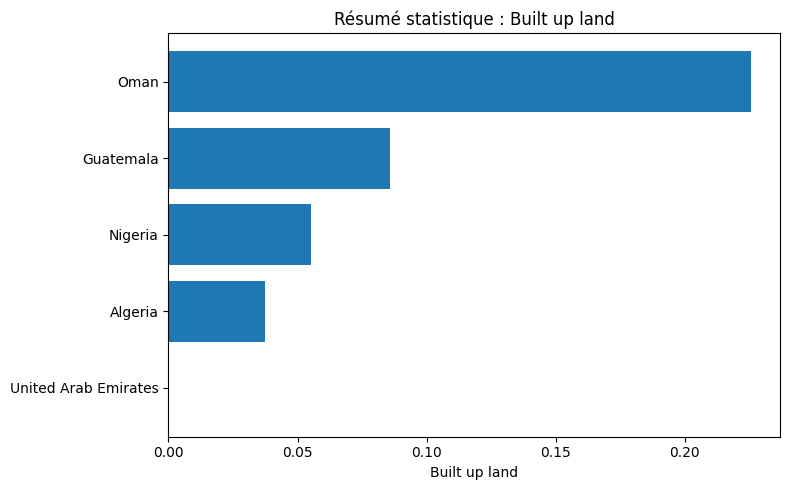

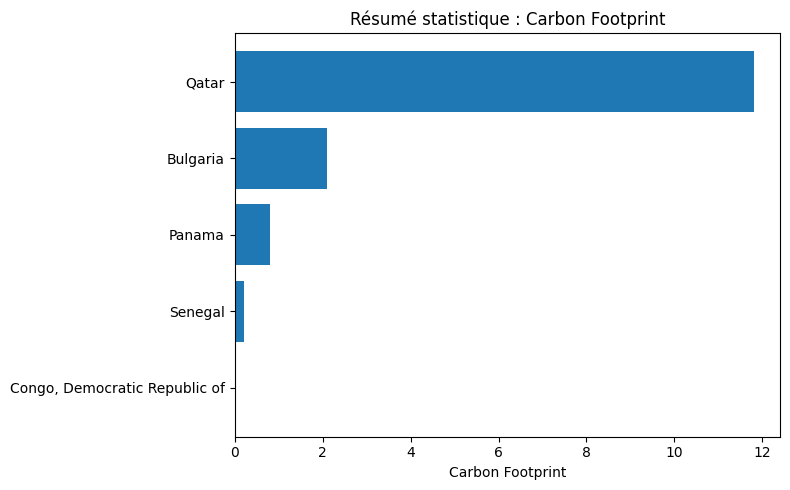

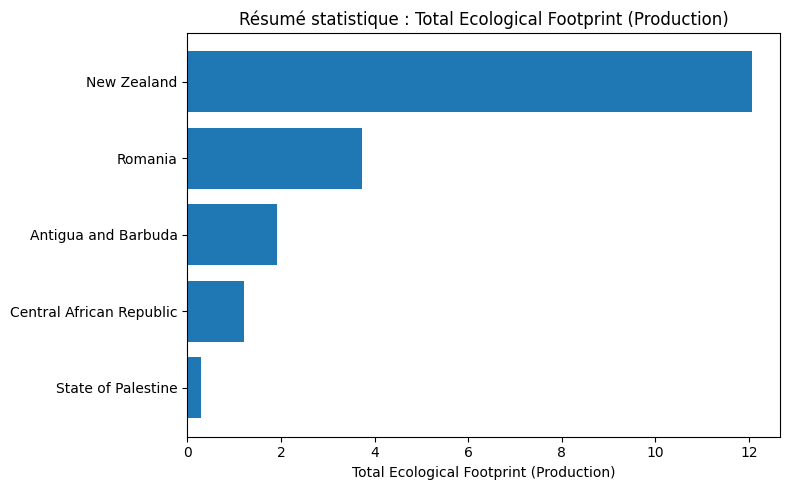

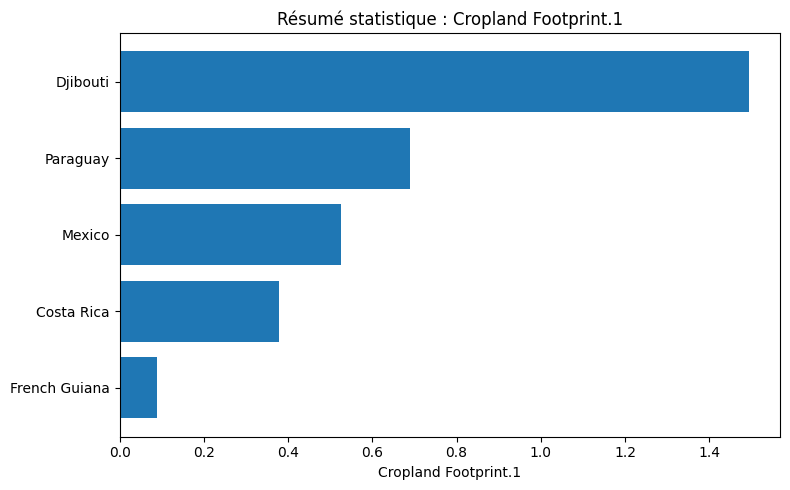

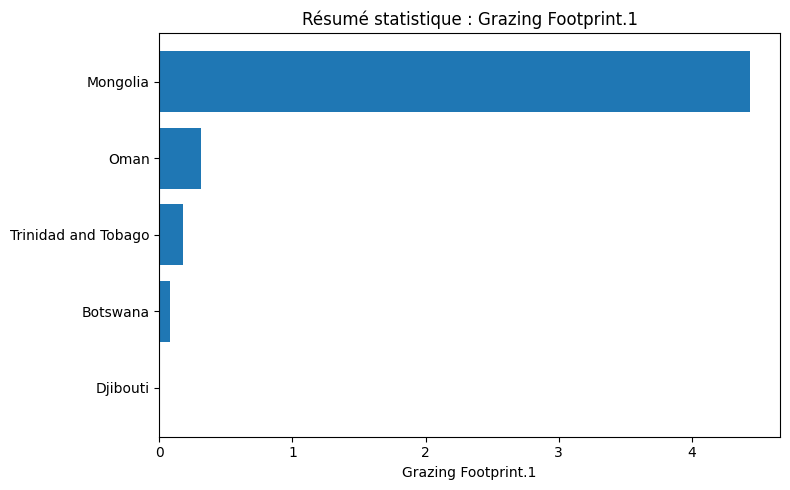

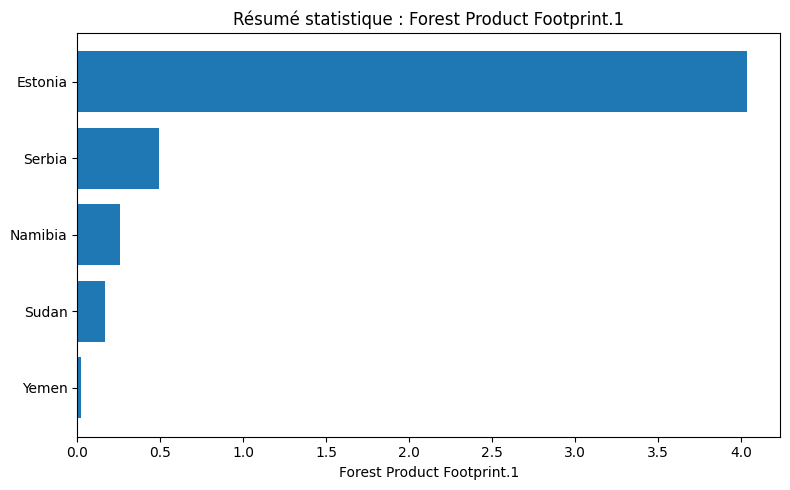

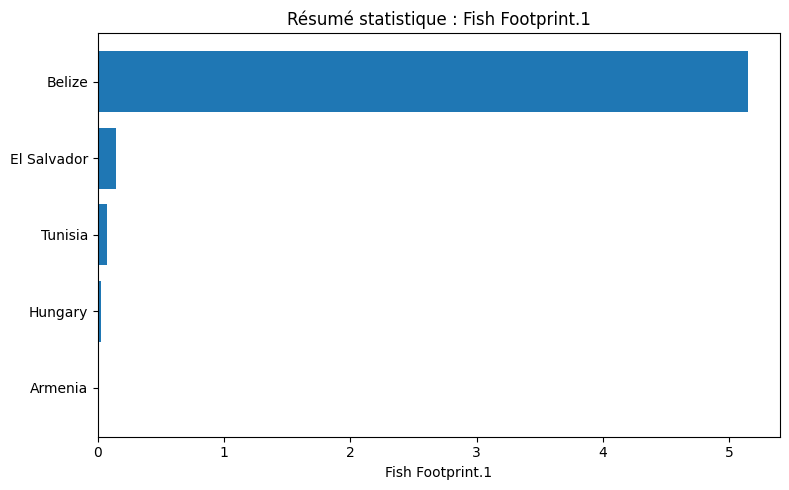

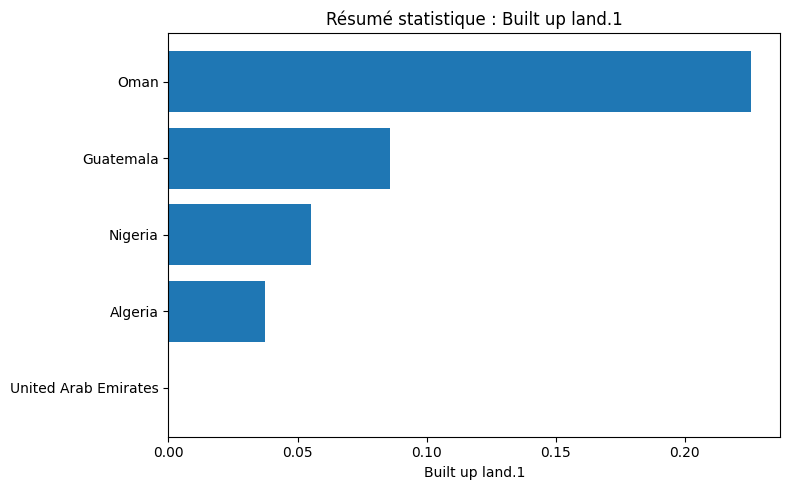

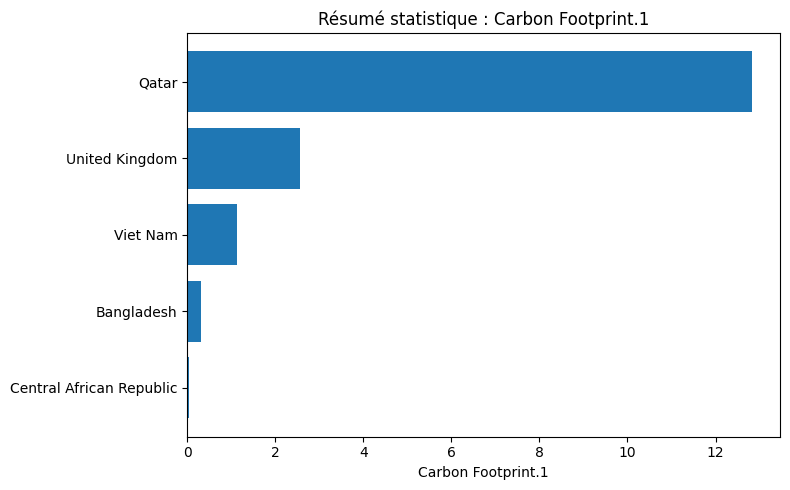

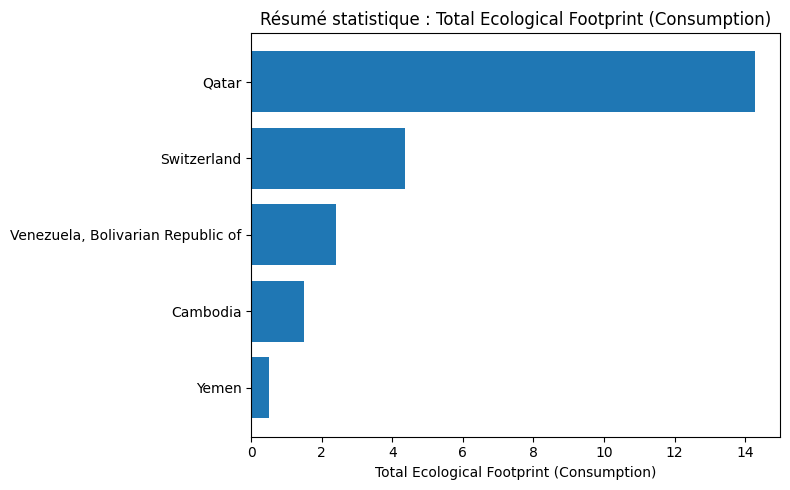

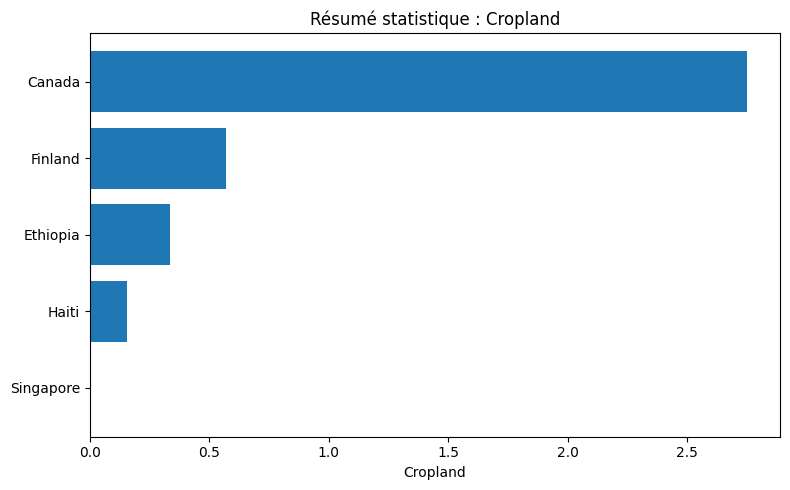

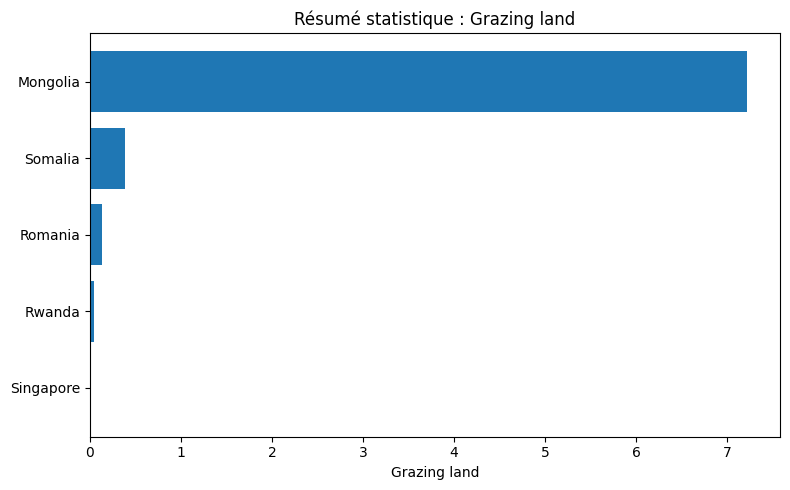

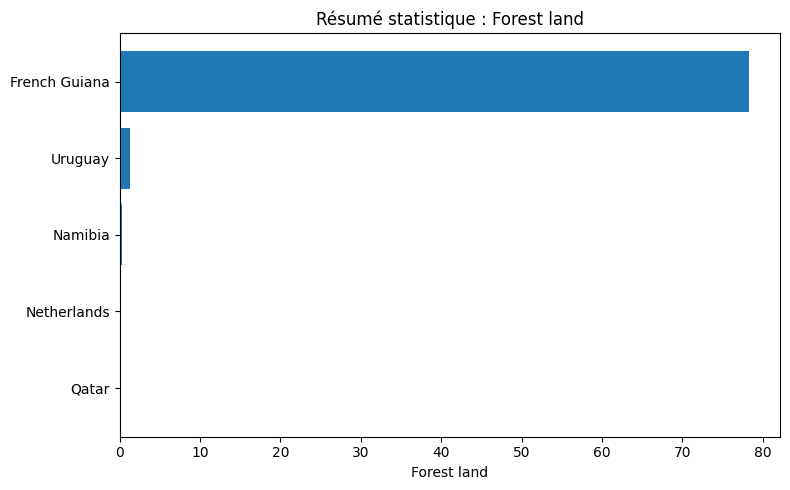

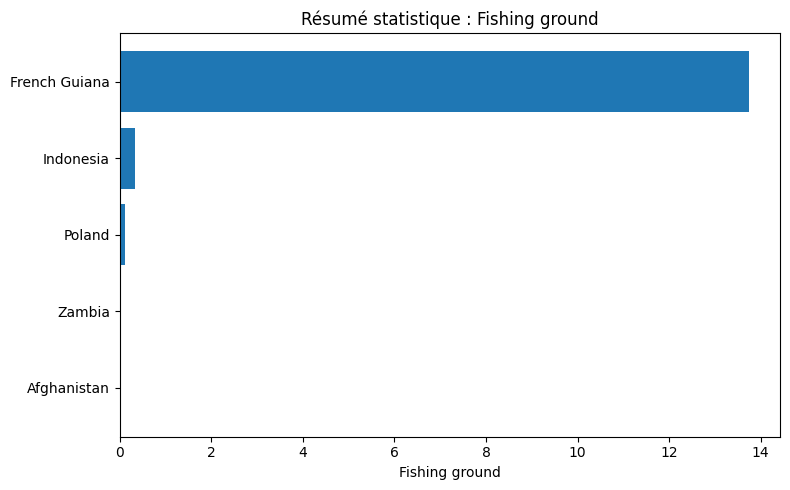

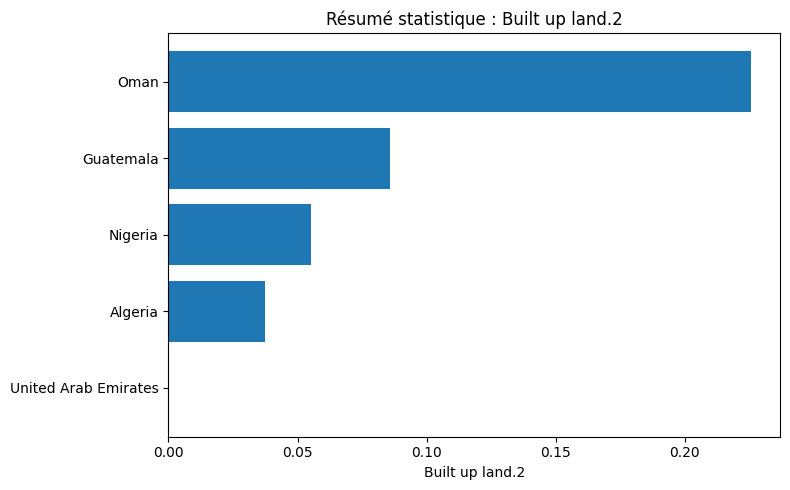

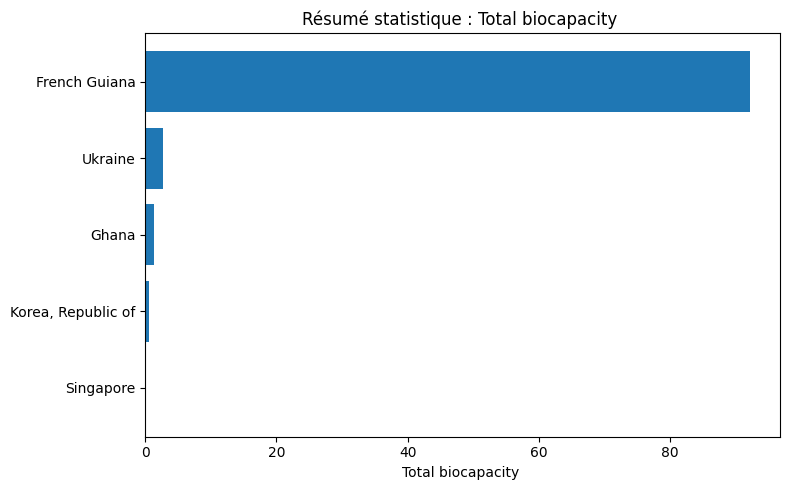

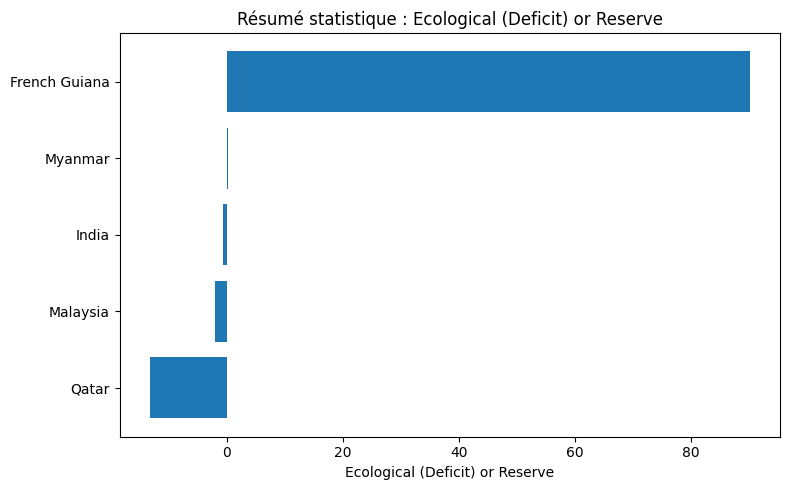

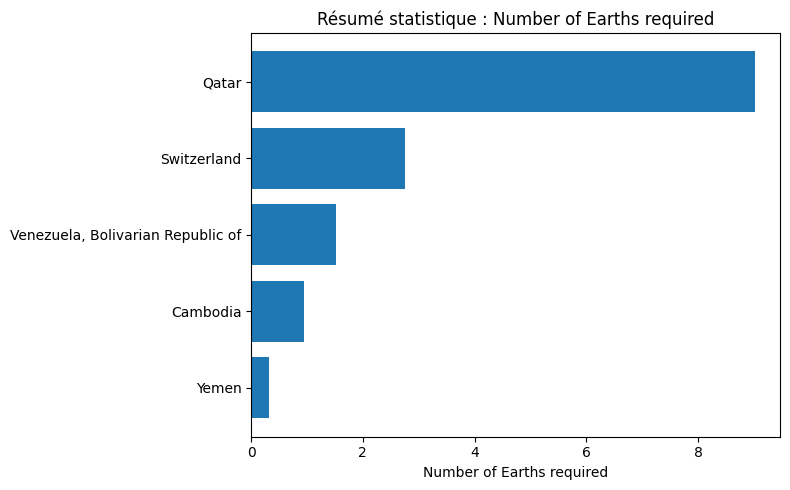

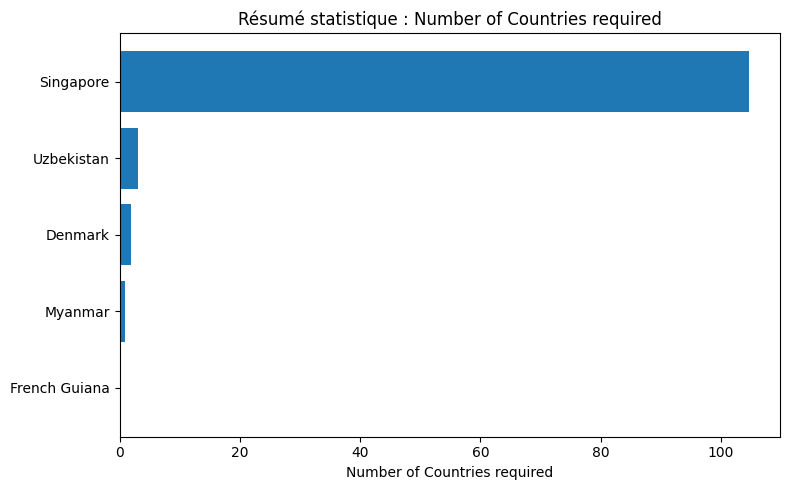

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

colonnes = df.columns

for col in colonnes:
    if col == "Country" or not pd.api.types.is_numeric_dtype(df[col]):
        continue

    pays_classe = df.sort_values(col)

    # Valeurs statistiques
    q1 = pays_classe[col].quantile(0.25)
    median = pays_classe[col].median()
    q3 = pays_classe[col].quantile(0.75)

    # On récupère l'index de la valeur la plus proche pour Q1, median, Q3
    idx_q1 = (pays_classe[col] - q1).abs().idxmin()
    idx_med = (pays_classe[col] - median).abs().idxmin()
    idx_q3 = (pays_classe[col] - q3).abs().idxmin()

    # Liste des index extrêmes
    idx_min = pays_classe[col].idxmin()
    idx_max = pays_classe[col].idxmax()

    # DataFrame contenant les 5 lignes désirées
    summary = pays_classe.loc[[idx_min, idx_q1, idx_med, idx_q3, idx_max]]

    plt.figure(figsize=(8,5))
    plt.barh(summary["Country"], summary[col])
    plt.xlabel(col)
    plt.title(f"Résumé statistique : {col}")
    plt.tight_layout()
    plt.show()

